# Report Sequence :

We have split the dataset into train & test & all analysis that we have performed is on our train set. This has been done so that our decision dont get influenced by datapoints which models might not see during training.

1) Dataset description : <br>
Use outputs of these sections.<br>
&emsp;a) df.describe() <br>
&emsp;b) df.unique() <br>
&emsp;c) df.count() <br>
<br>
2) Univariate Analysis : <br>
Use outputs of these sections.<br>
&emsp; a) Box plots - For numerical <br>
&emsp; b) Histograms - For categorical & numerical. <br>
<br>
3) Multivariate - <br>
Use outputs of these sections.<br>
&emsp; a) Pearson correlation coeff <br>
&emsp; b) Correlation heatmap <br>
<br>
4) Bivariate - Scatter plots & line plots.<br>
5) Handling Missing Values <br>
6) De-duplication : We have observed that the dataset contains high no.of duplicates. We have removed such duplicates before training. <br>
7) Biases in dataset (if any)

Add the observations that are present in this .ipynb file.


In [1]:
import pandas as pd

df = pd.read_csv("/content/train_data.csv")
df.head()

,age,workclass,education,educationno,maritalstatus,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native,Possibility
0,35,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,1
1,23,Private,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40.0,United-States,0
2,39,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,60.0,United-States,1
3,33,Private,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,32.0,United-States,0
4,27,Self-emp-inc,HS-grad,9,Separated,Adm-clerical,Not-in-family,White,Male,0,0,38.0,United-States,0


In [2]:
df.describe()

,age,educationno,capitalgain,capitalloss,hoursperweek,Possibility
count,21112.000000,21112.000000,21112.000000,21112.000000,20794.000000,21112.000000
mean,38.285004,10.129452,1124.986974,87.479585,40.992883,0.248153
std,13.161197,2.552163,7529.845515,401.632019,11.986292,0.431951
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [3]:
df.nunique()

,0
age,71
workclass,7
education,16
educationno,16
maritalstatus,7
occupation,14
relationship,6
race,5
sex,2
capitalgain,116


In [4]:
df.count()

,0
age,21112
workclass,21112
education,21112
educationno,21112
maritalstatus,20976
occupation,21112
relationship,21112
race,20636
sex,20883
capitalgain,21112


Some rows have count < 21112. This means they are missing values.

## Univariate Analysis

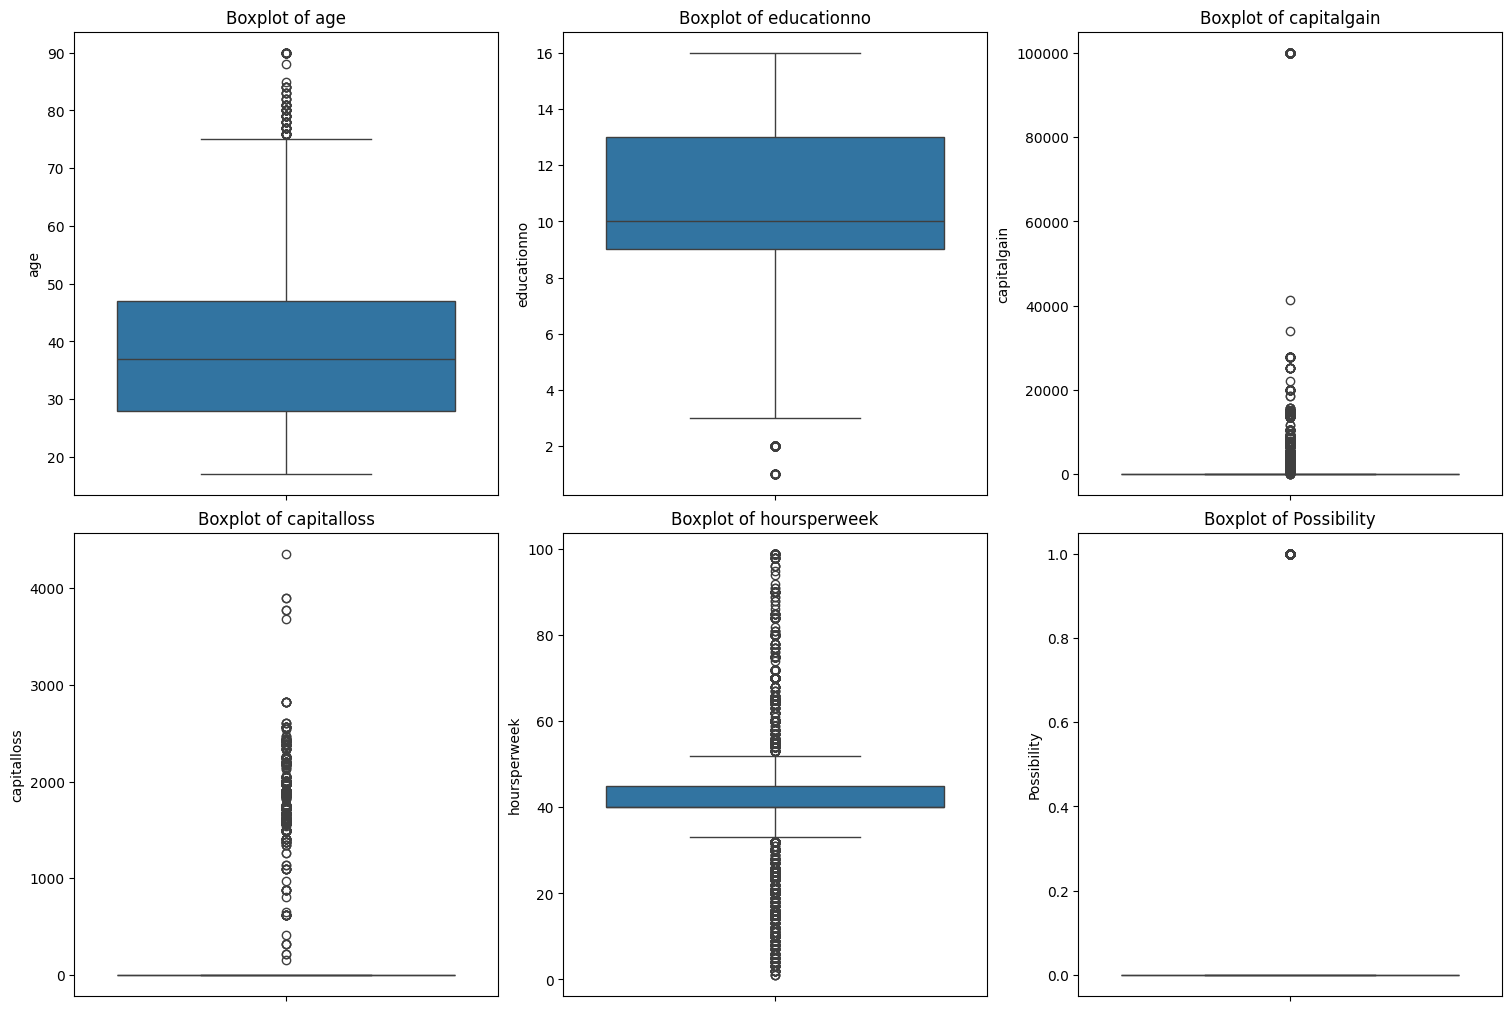

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_features = df.select_dtypes(include=['number']).columns

# Determine the number of features and set up subplots
num_features = len(numerical_features)
num_cols = 3  # Number of columns in subplot grid
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate rows needed

# Create a figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), constrained_layout=True)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot boxplots for each numerical feature
for i, feature in enumerate(numerical_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Show the plot
plt.show()

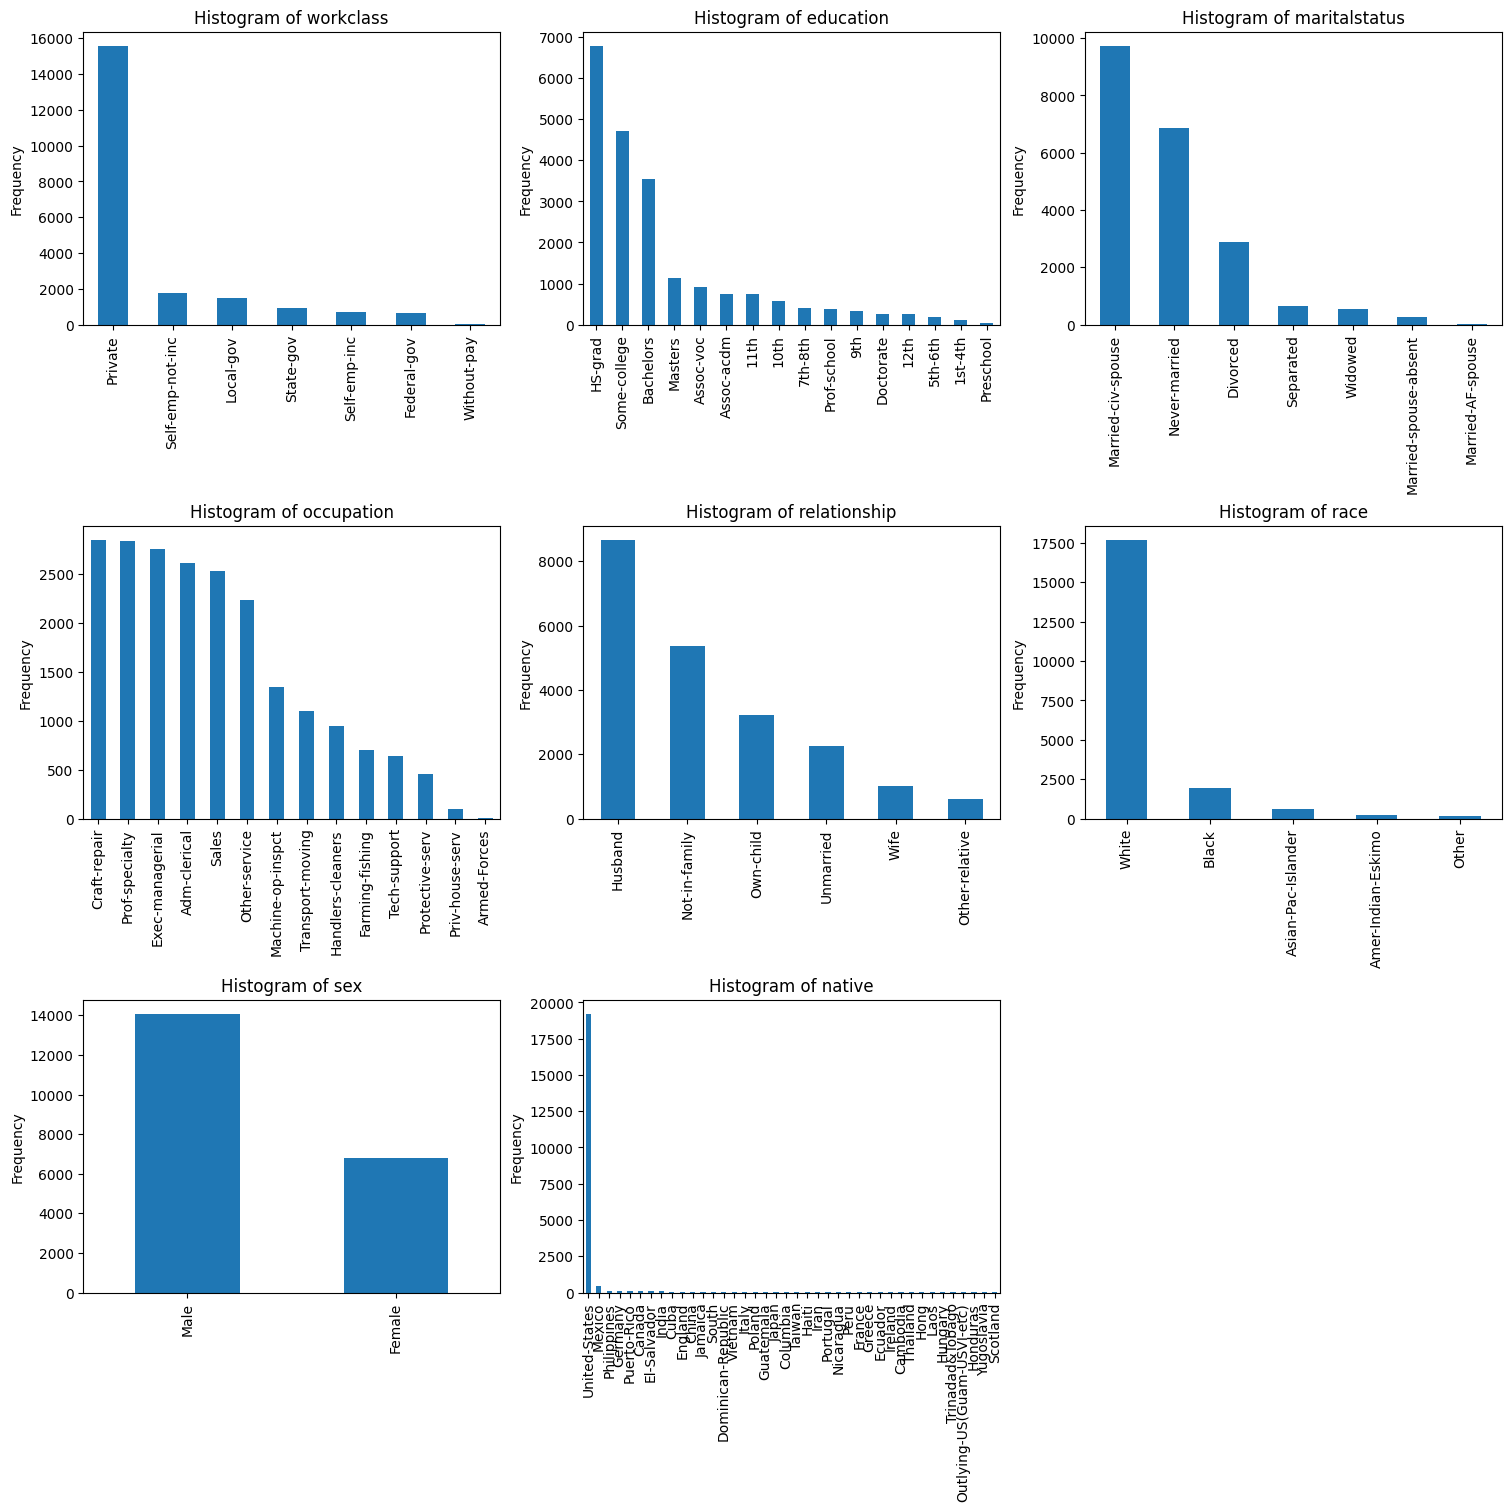

In [7]:
# Select only categorical columns
categorical_features = df.select_dtypes(include=['object']).columns

# Determine the number of features and set up subplots
num_features = len(categorical_features)
num_cols = 3  # Number of columns in subplot grid
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate rows needed

# Create a figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows), constrained_layout=True)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot histograms for each categorical feature
for i, feature in enumerate(categorical_features):
    df[feature].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Show the plot
plt.show()

**Observations :-**<br>
1) Most people work in private companies.<br>
2) Presence of high no.of Category - "White". <br>
3) Most people are US citizens,

## Multivariate analysis

In [8]:
# Compute Pearson correlation matrix for numerical features
correlation_matrix = df.select_dtypes(include=['number']).corr()

print(correlation_matrix)

                   age  educationno  capitalgain  capitalloss  hoursperweek  \
age           1.000000     0.048571     0.085439     0.056397      0.102345   
educationno   0.048571     1.000000     0.132090     0.075064      0.146205   
capitalgain   0.085439     0.132090     1.000000    -0.032543      0.084525   
capitalloss   0.056397     0.075064    -0.032543     1.000000      0.045774   
hoursperweek  0.102345     0.146205     0.084525     0.045774      1.000000   
Possibility   0.247566     0.334027     0.226576     0.140165      0.224251   

              Possibility  
age              0.247566  
educationno      0.334027  
capitalgain      0.226576  
capitalloss      0.140165  
hoursperweek     0.224251  
Possibility      1.000000  


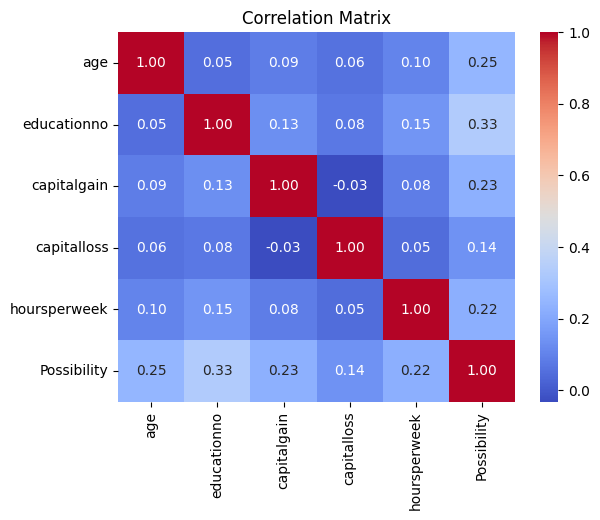

In [9]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Bivariate Analysis
Need to discuss this, plots dont make much sense. No trends found.

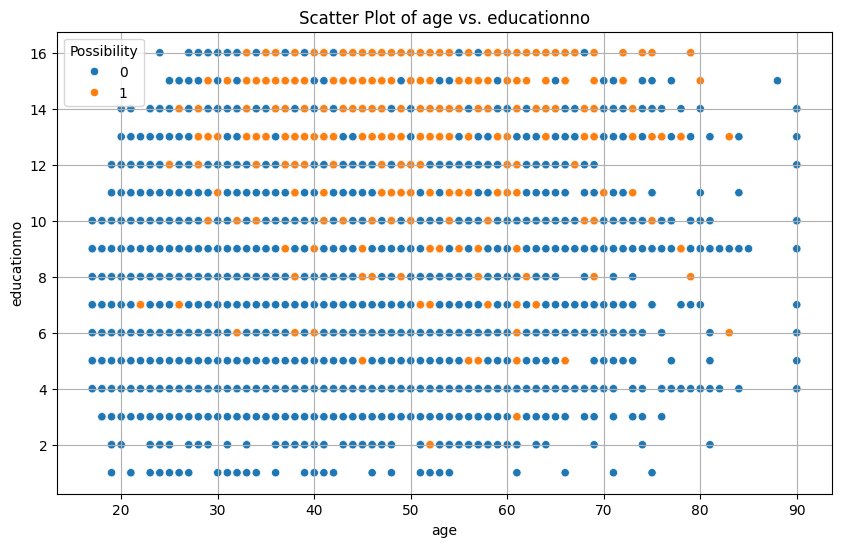

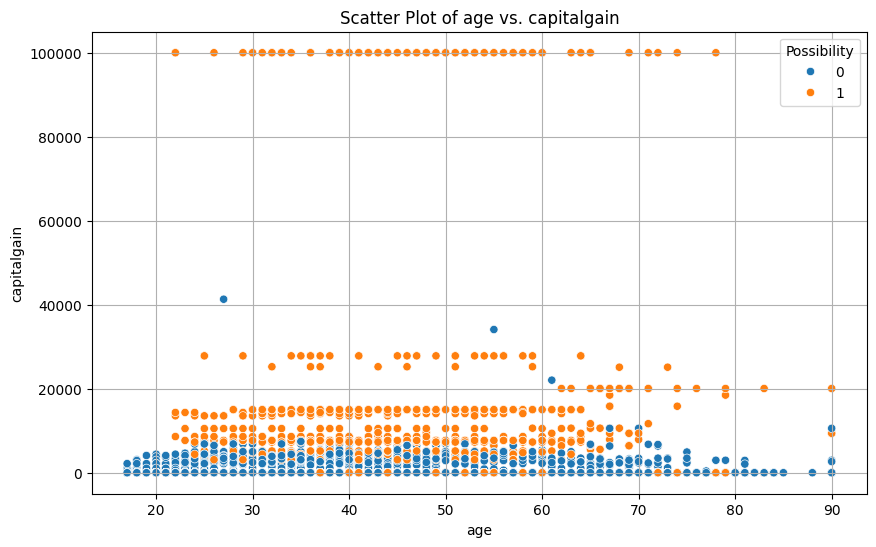

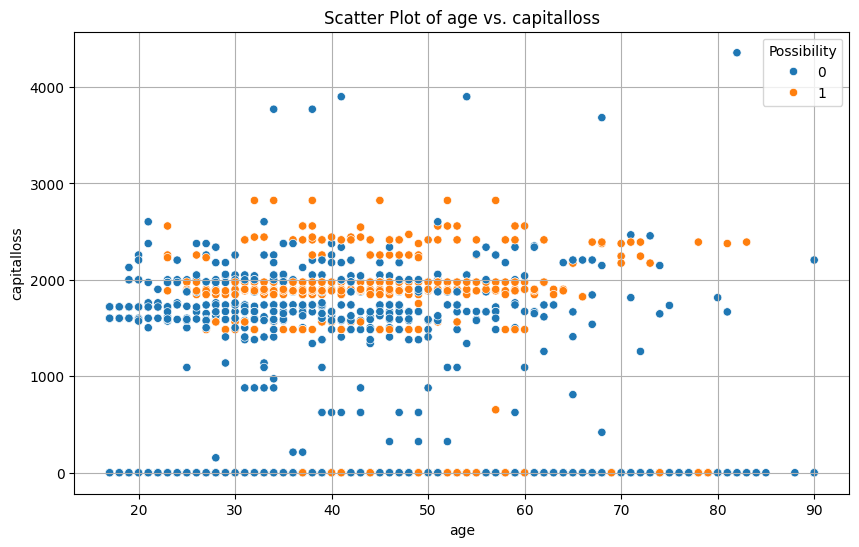

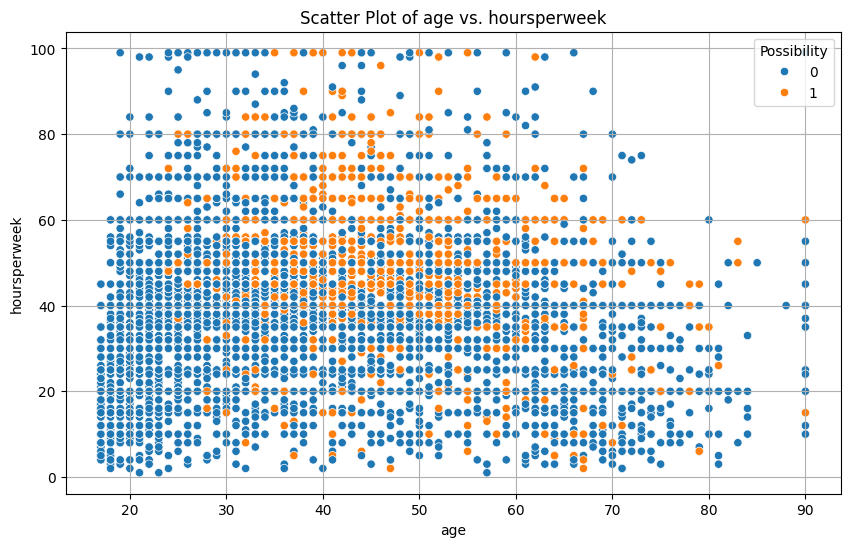

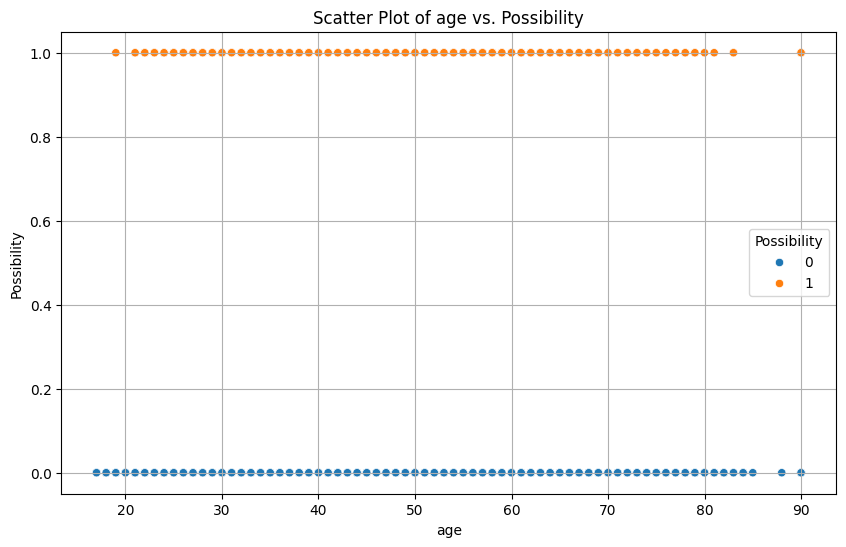

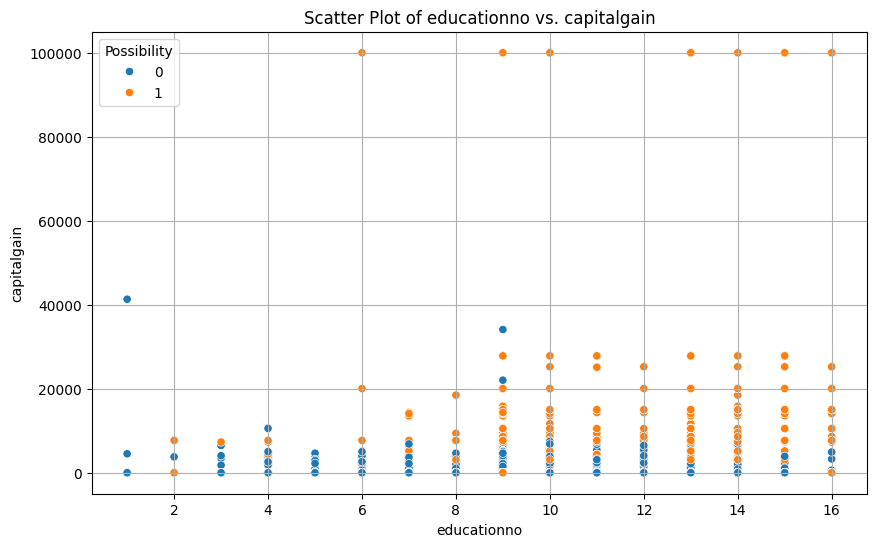

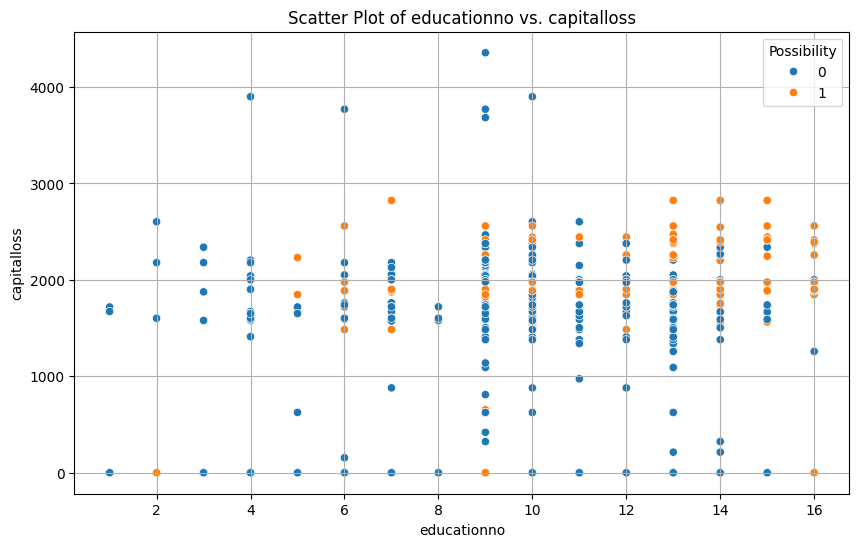

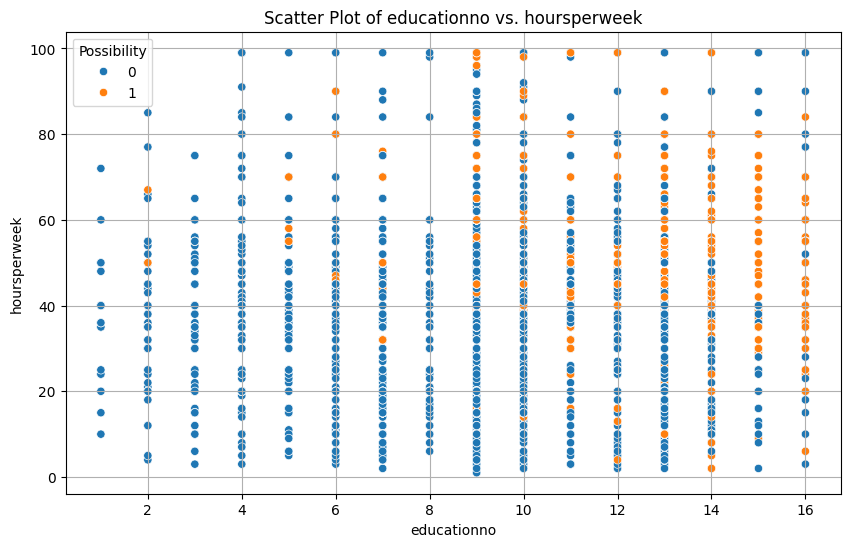

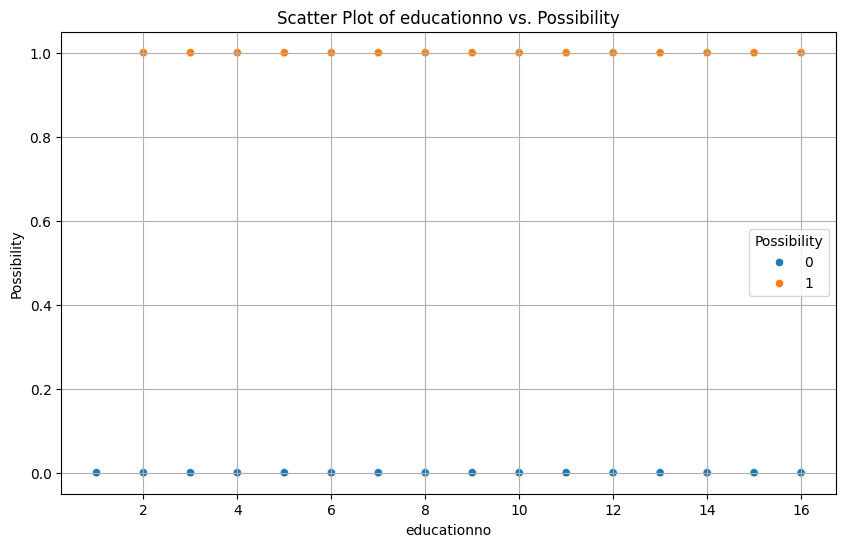

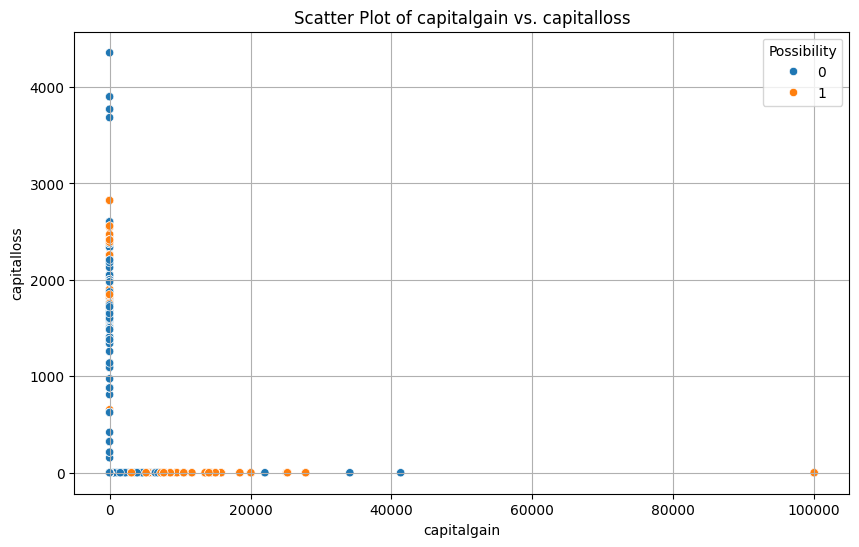

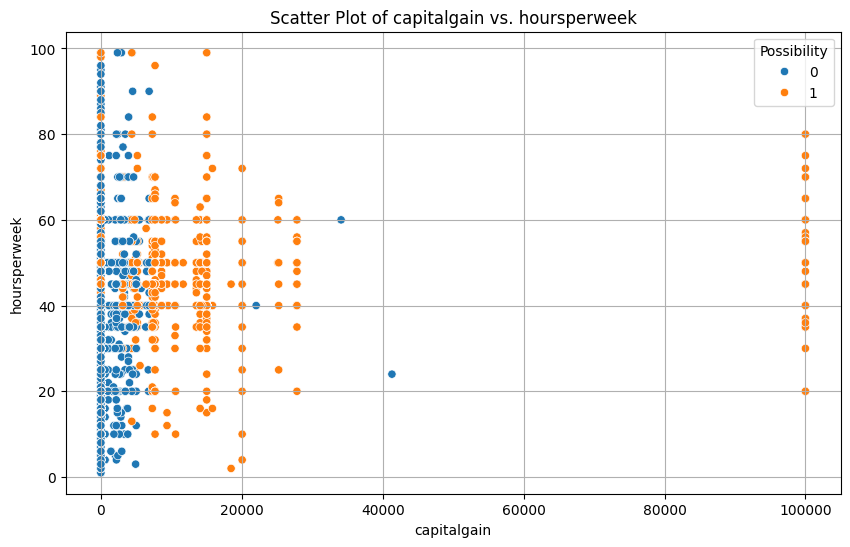

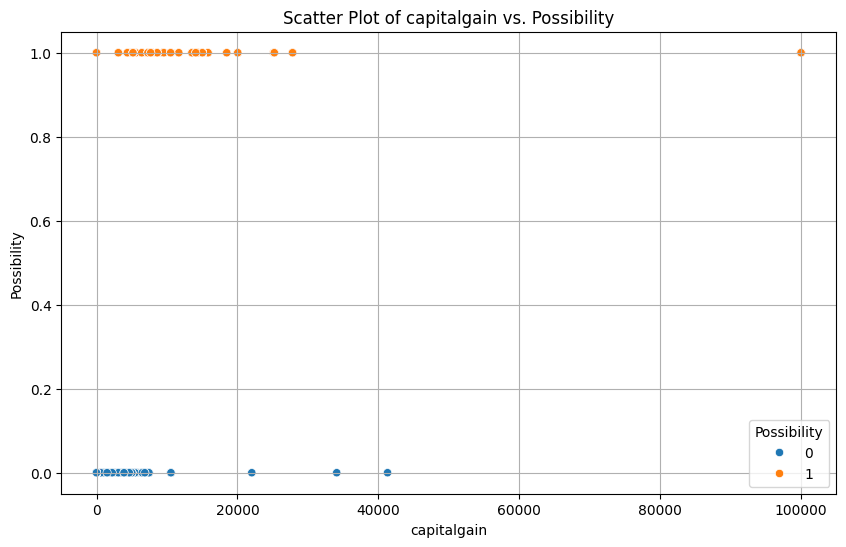

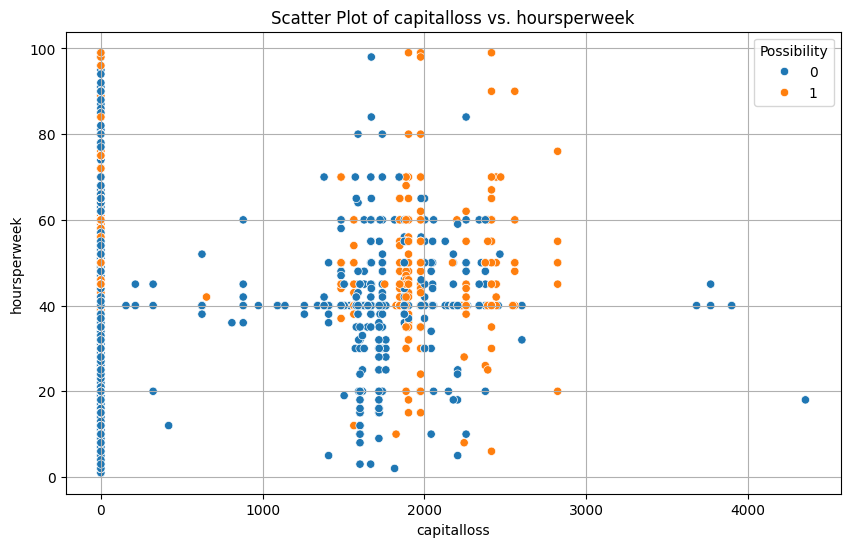

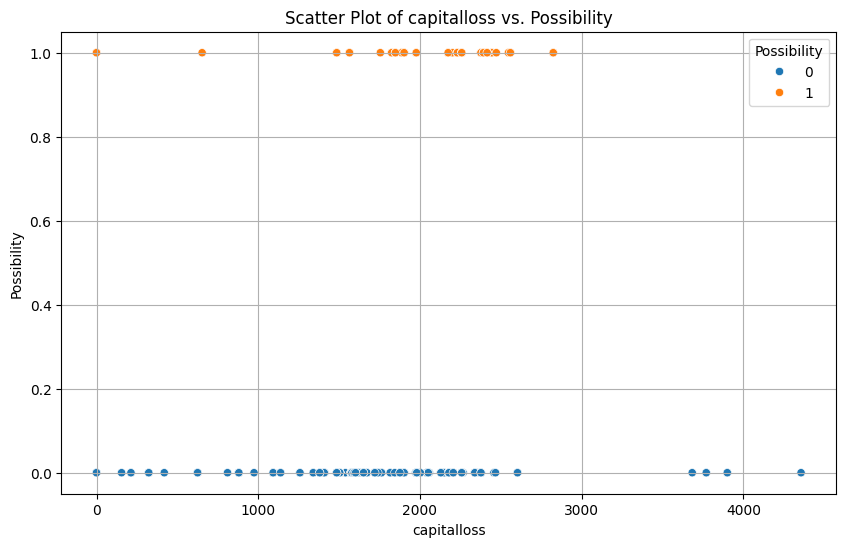

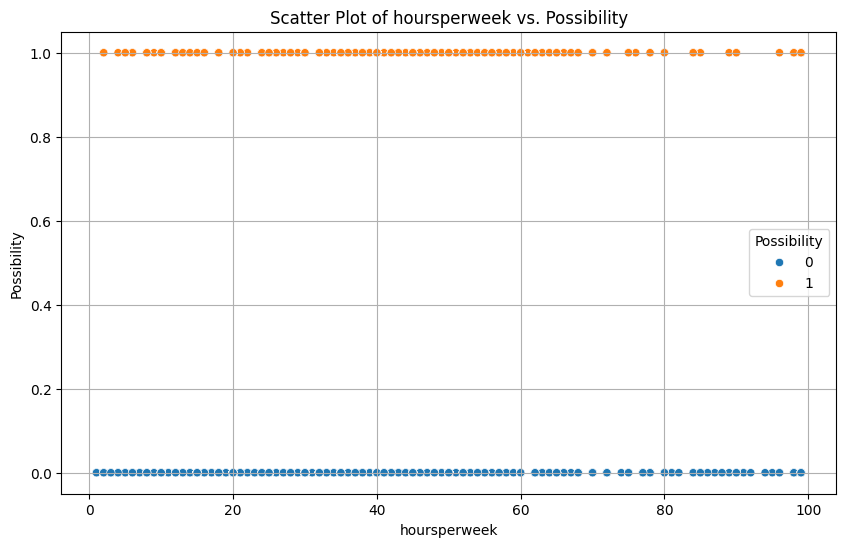

In [10]:
for i in range(len(numerical_features)):
    for j in range(i + 1, len(numerical_features)):
        col1 = numerical_features[i]
        col2 = numerical_features[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2, hue='Possibility')  # You can change 'hue' to another categorical column
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.title(f'Scatter Plot of {col1} vs. {col2}')
        plt.grid(True)
        plt.show()

## Is the dataset imbalanced ?

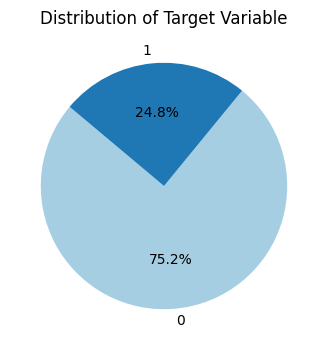

In [12]:
# Count the occurrences of each category in the target variable
target_counts = df['Possibility'].value_counts()

# Plot pie chart
plt.figure(figsize=(4, 4))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(target_counts))))
plt.title('Distribution of Target Variable')
plt.show()

**Observation :-**
Dataset is imbalanced. About 1/4th of the dataset contains potential criminals.

## 6) Finding Missing values

In [ ]:
missing_count = df.isnull().sum()
sorted_missing_count = missing_count.sort_values(ascending=False)
sorted_missing_count

,0
race,476
hoursperweek,318
sex,229
maritalstatus,136
age,0
workclass,0
education,0
educationno,0
occupation,0
relationship,0


In [ ]:
# Identify categorical columns. Datatypes that are either object or category are usually categorical in nature.
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Count instances for each categorical column
counts = {col: df[col].value_counts() for col in categorical_columns}

# Print the counts for each categorical column
for col, count in counts.items():
    print(f"Counts for '{col}':")
    print(count)
    print()

Counts for 'workclass':
workclass
Private             15585
Self-emp-not-inc     1767
Local-gov            1465
State-gov             909
Self-emp-inc          727
Federal-gov           647
Without-pay            12
Name: count, dtype: int64

Counts for 'education':
education
HS-grad         6791
Some-college    4714
Bachelors       3546
Masters         1124
Assoc-voc        911
Assoc-acdm       736
11th             734
10th             584
7th-8th          397
Prof-school      387
9th              331
Doctorate        268
12th             266
5th-6th          188
1st-4th          102
Preschool         33
Name: count, dtype: int64

Counts for 'maritalstatus':
maritalstatus
Married-civ-spouse       9740
Never-married            6874
Divorced                 2886
Separated                 641
Widowed                   556
Married-spouse-absent     267
Married-AF-spouse          12
Name: count, dtype: int64

Counts for 'occupation':
occupation
Craft-repair         2851
Prof-specialty     

## 3) Finding duplicates in the dataset

In [ ]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 1667


We can follow either of the 2 following strategies to deal with duplicates :-

a) Delete all duplicates of a row.\
b) Delete all but one, i.e, keep one of the duplicated rows.

## 8) Biases in dataset (if any)
Here we tried to find if the dataset got biased during collection. We focussed on the following :-

&emsp; a) How likely is it for non-Americans to be potential suspects ? <br>
&emsp; b) Is there any racial bias ? <br>

### a) How likely is it for non-Americans to be potential suspects ?

In [ ]:
def isAmerican(native):
  if native == "United-States":
    return 1
  else:
    return 0

df["IsAmerican"] = df["native"].apply(isAmerican)
df.head()

,age,workclass,education,educationno,maritalstatus,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native,Possibility,IsAmerican
0,35,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States,1,1
1,23,Private,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40.0,United-States,0,1
2,39,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,60.0,United-States,1,1
3,33,Private,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,32.0,United-States,0,1
4,27,Self-emp-inc,HS-grad,9,Separated,Adm-clerical,Not-in-family,White,Male,0,0,38.0,United-States,0,1


In [ ]:
# Finding no.of Americans & Non-Americans
num_US_people = df["IsAmerican"].sum()
num_non_US_people = len(df) - num_US_people

# Finding no.of American potential guilty
condition1 = (df["Possibility"] == 1) & (df["IsAmerican"] == 1)
num_US_suspects = condition1.sum()

# Finding no.of non-American potential guilty
condition2 = (df["Possibility"] == 1) & (df["IsAmerican"] == 0)
num_non_US_suspects = condition2.sum()

print("Probability of an American to be potential criminal : {}".format(num_US_suspects/num_US_people))
print("Probability of a non-American to be potential criminal : {}".format(num_non_US_suspects/num_non_US_people))

Probability of an American to be potential criminal : 0.25331530500806076
Probability of a non-American to be potential criminal : 0.19543281996813594


### b) Is there any racial bias ?
Are white people more likely to be suspected than black people or people belonging to other racial groups ?

In [ ]:
def isWhite(race):
  if race == "White":
    return 1
  else:
    return 0

def isBlack(race):
  if race == "Black":
    return 1
  else:
    return 0

def isAsianPacIslander(race):
  if race == "Asian-Pac-Islander":
    return 1
  else:
    return 0

def isAmerIndianEskimo(race):
  if race == "Amer-Indian-Eskimo":
    return 1
  else:
    return 0

def isOther(race):
  if race == "Other":
    return 1
  else:
    return 0


df["IsWhite"] = df["race"].apply(isWhite)
df["IsBlack"] = df["race"].apply(isBlack)
df["IsAsianPacIslander"] = df["race"].apply(isAsianPacIslander)
df["IsAmerIndianEskimo"] = df["race"].apply(isAmerIndianEskimo)
df["IsOther"] = df["race"].apply(isOther)

num_white_people = df["IsWhite"].sum()
num_black_people = df["IsBlack"].sum()
num_asianpacisl_people = df["IsAsianPacIslander"].sum()
num_amer_indian_eskimo_people = df["IsAmerIndianEskimo"].sum()
num_other_people = df["IsOther"].sum()

condition3 = (df["Possibility"] == 1) & (df["IsWhite"]==1)
num_white_suspects = condition3.sum()

condition4 = (df["Possibility"] == 1) & (df["IsBlack"]==1)
num_black_suspects = condition4.sum()

condition5 = (df["Possibility"] == 1) & (df["IsAsianPacIslander"]==1)
num_asianpacisl_suspects = condition5.sum()

condition6 = (df["Possibility"] == 1) & (df["IsAmerIndianEskimo"]==1)
num_amerindianesk_suspects = condition6.sum()

condition7 = (df["Possibility"] == 1) & (df["IsOther"]==1)
num_other_suspects = condition7.sum()

print("Probability of an White to be potential criminal : {}".format(num_white_suspects/num_white_people))
print("Probability of a Black to be potential criminal : {}".format(num_black_suspects/num_white_people))
print("Probability of an Asian-Pac-Islander to be potential criminal : {}".format(num_asianpacisl_suspects/num_asianpacisl_people))
print("Probability of an Amer-Indian-Eskimo to be potential criminal : {}".format(num_amerindianesk_suspects/num_amer_indian_eskimo_people))
print("Probability of an Other to be potential criminal : {}".format(num_other_suspects/num_other_people))

Probability of an White to be potential criminal : 0.2630984004973718
Probability of a Black to be potential criminal : 0.013903803764200532
Probability of an Asian-Pac-Islander to be potential criminal : 0.27639751552795033
Probability of an Amer-Indian-Eskimo to be potential criminal : 0.13145539906103287
Probability of an Other to be potential criminal : 0.09316770186335403


**Observations :-**<br>
1) Whites are 20 times more likely to be potential criminals than Blacks.

## Data Visualizations

In [ ]:
df["Profit"] = df["capitalgain"] - df["capitalloss"]
df.head(2)

,age,workclass,education,educationno,maritalstatus,occupation,relationship,race,sex,capitalgain,...,hoursperweek,native,Possibility,IsAmerican,IsWhite,IsBlack,IsAsianPacIslander,IsAmerIndianEskimo,IsOther,Profit
0,35,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,...,40.0,United-States,1,1,1,0,0,0,0,0
1,23,Private,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,...,40.0,United-States,0,1,1,0,0,0,0,0


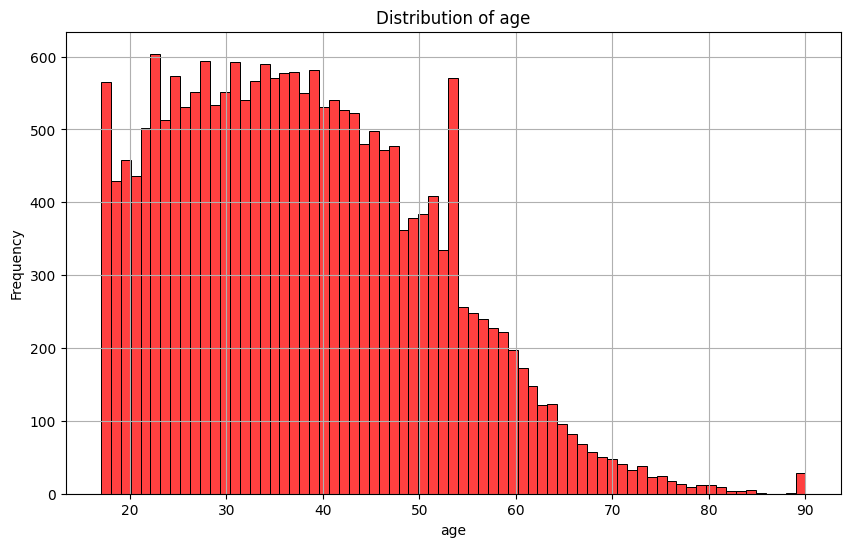

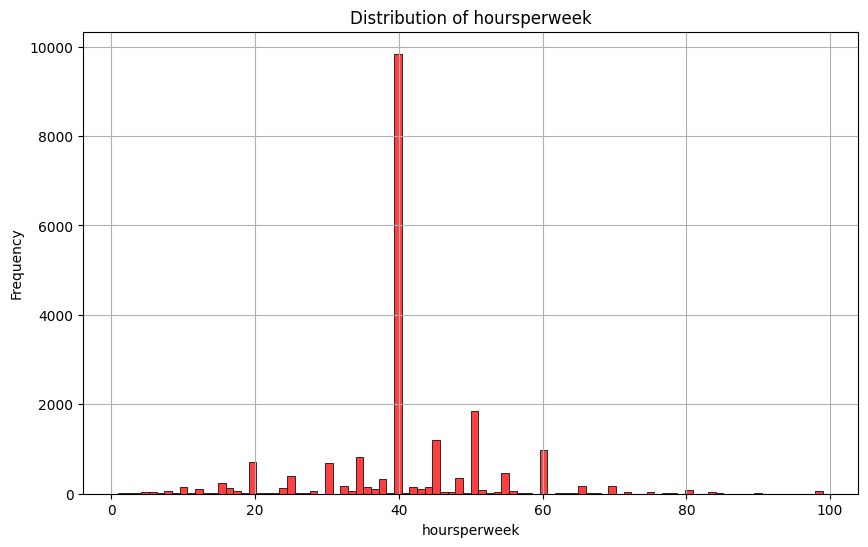

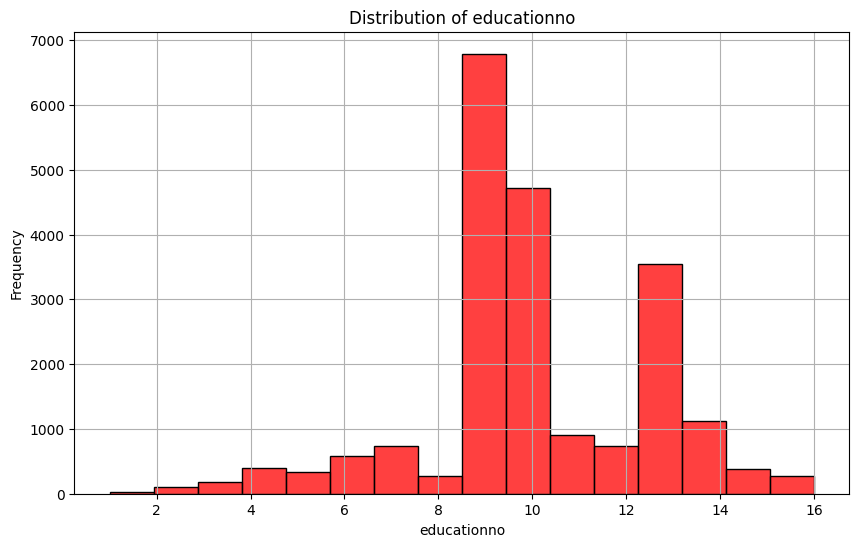

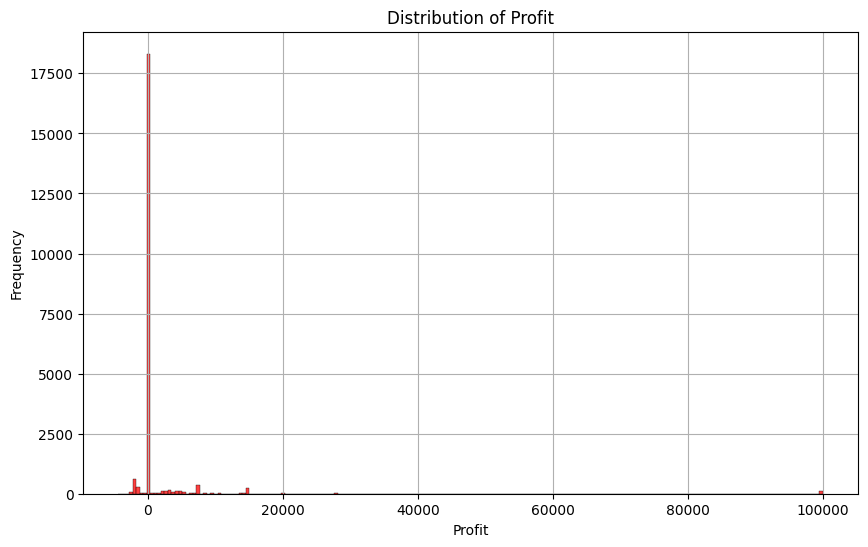

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['age', 'hoursperweek', 'educationno', 'Profit']  # Add other numerical columns
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], bins=df[col].nunique(), kde=False, color='red', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.grid(True)
    plt.show()

This would help in feature binning for age, hoursperweek.

## 2) Countplots for categorical features

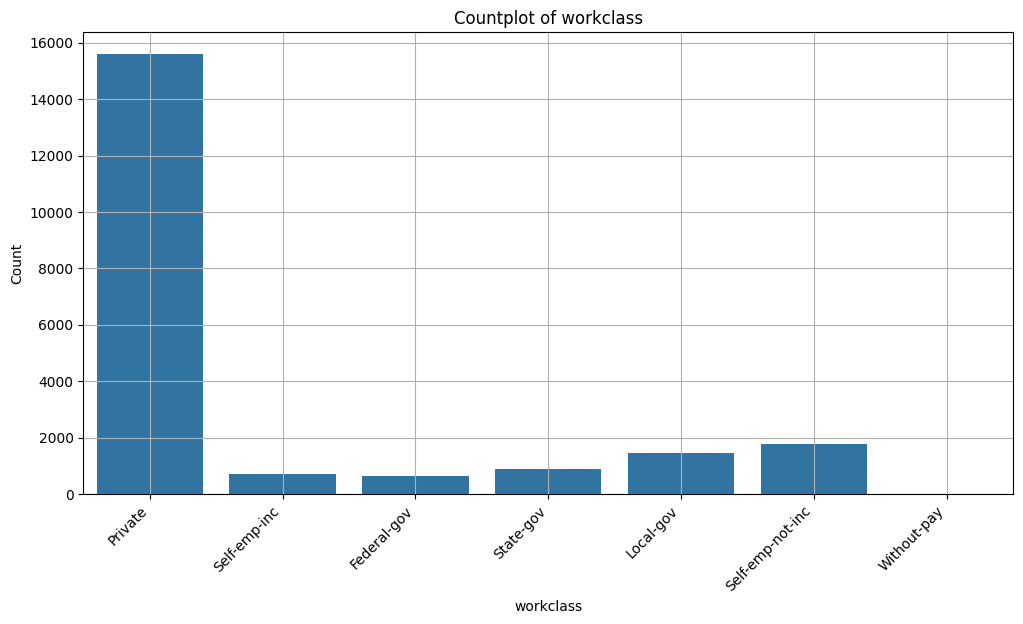

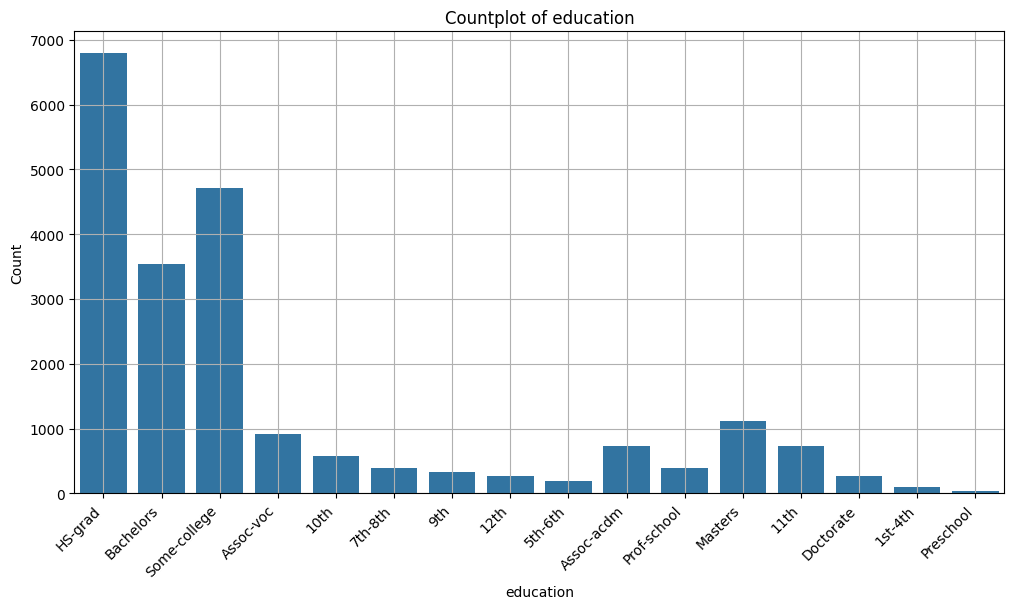

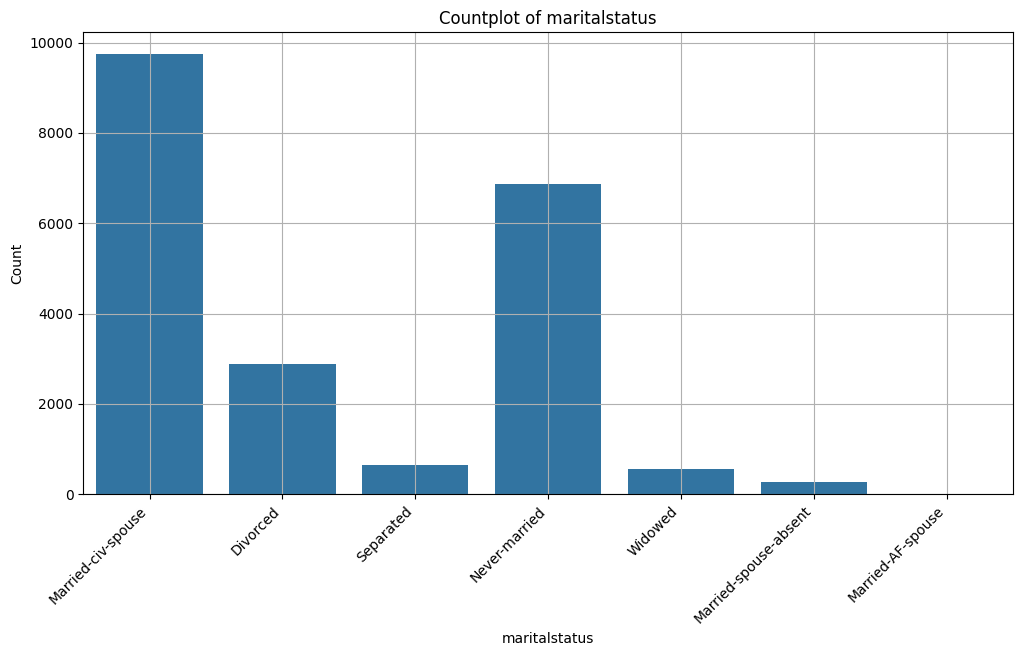

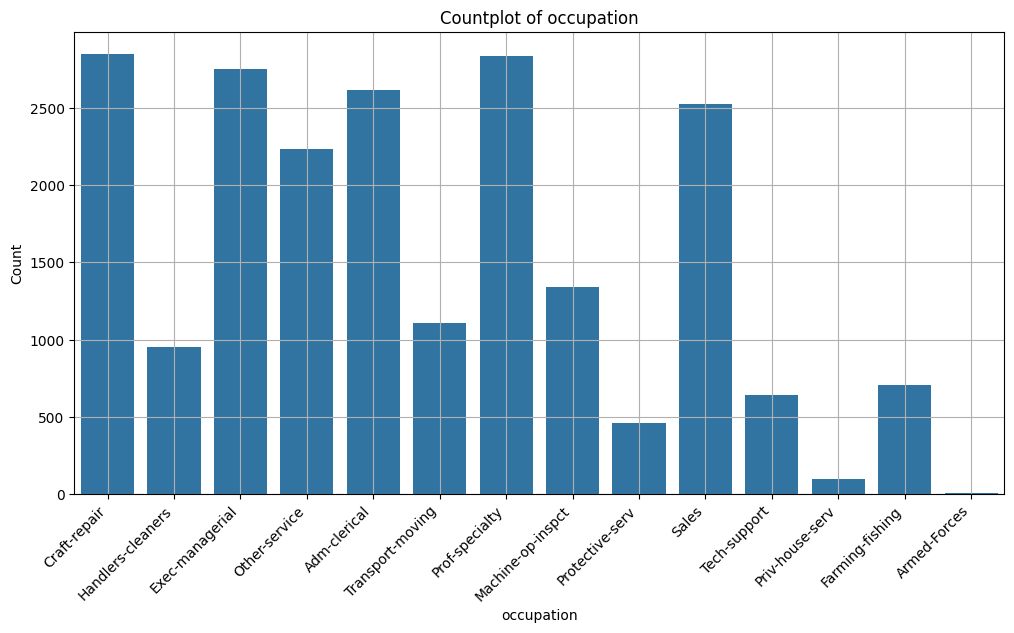

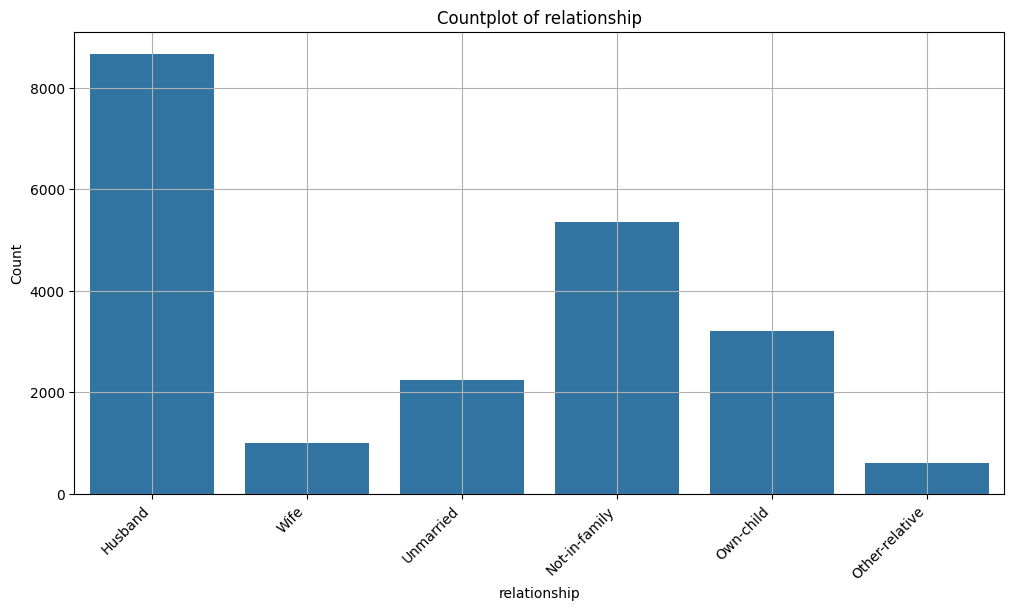

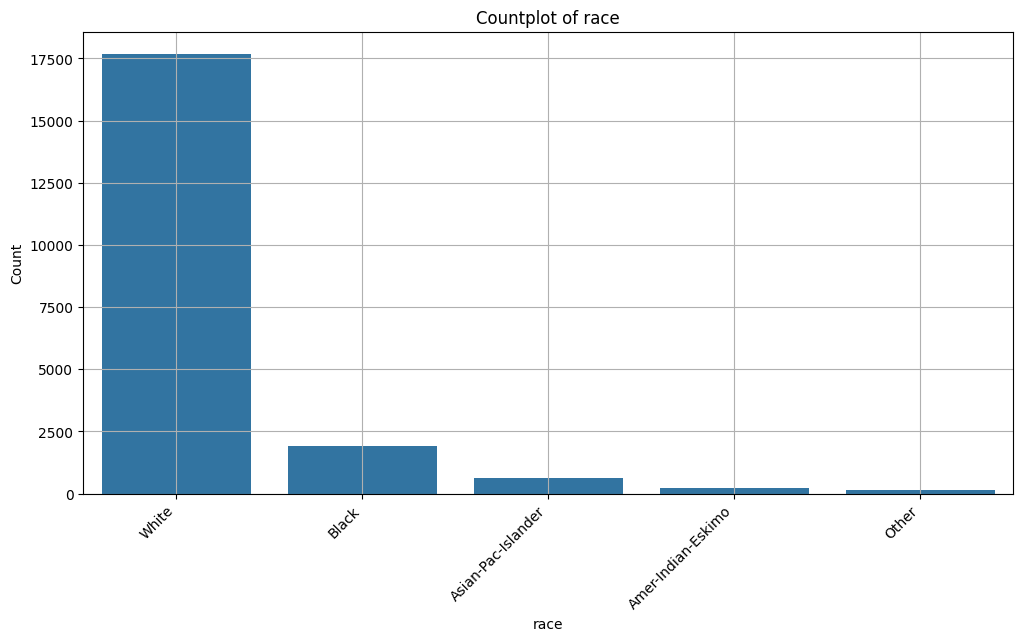

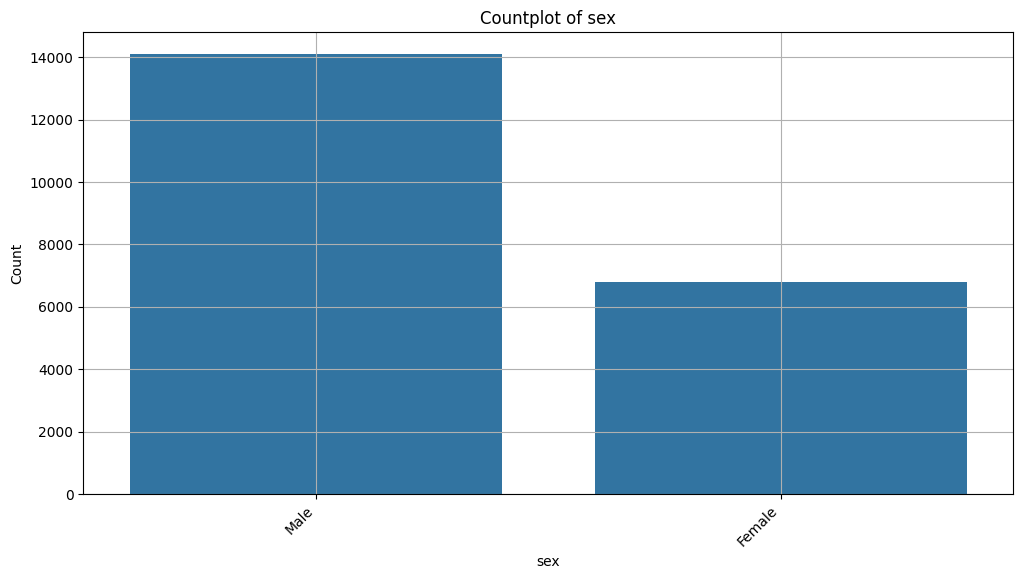

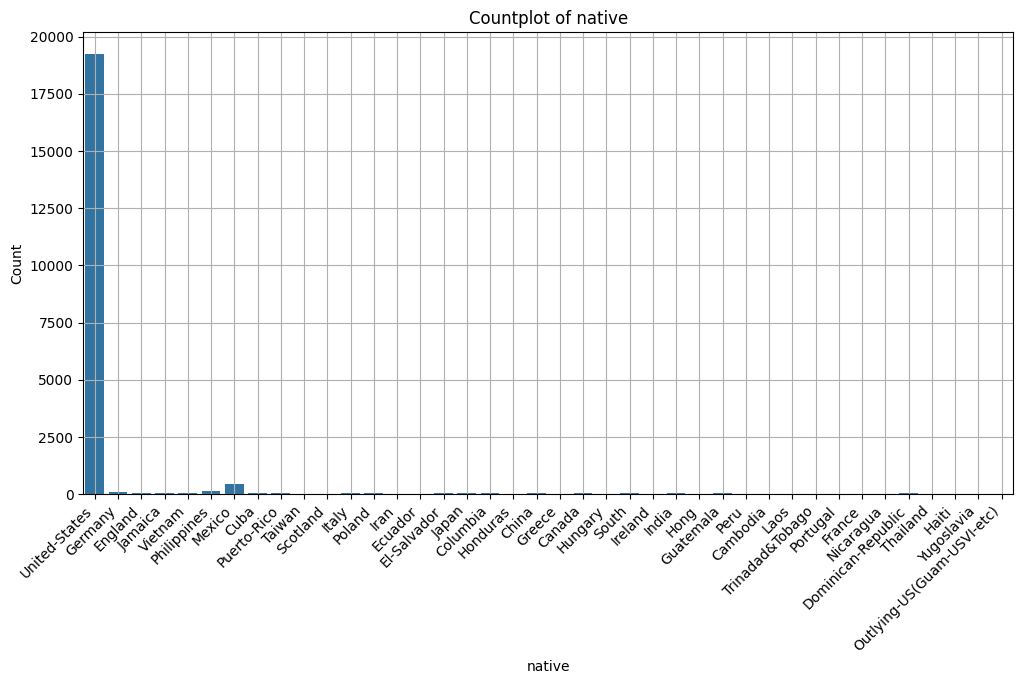

In [ ]:
for col in categorical_columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if needed
    plt.grid(True)
    plt.show()

## 3) Box plots for numerical vs categorical features

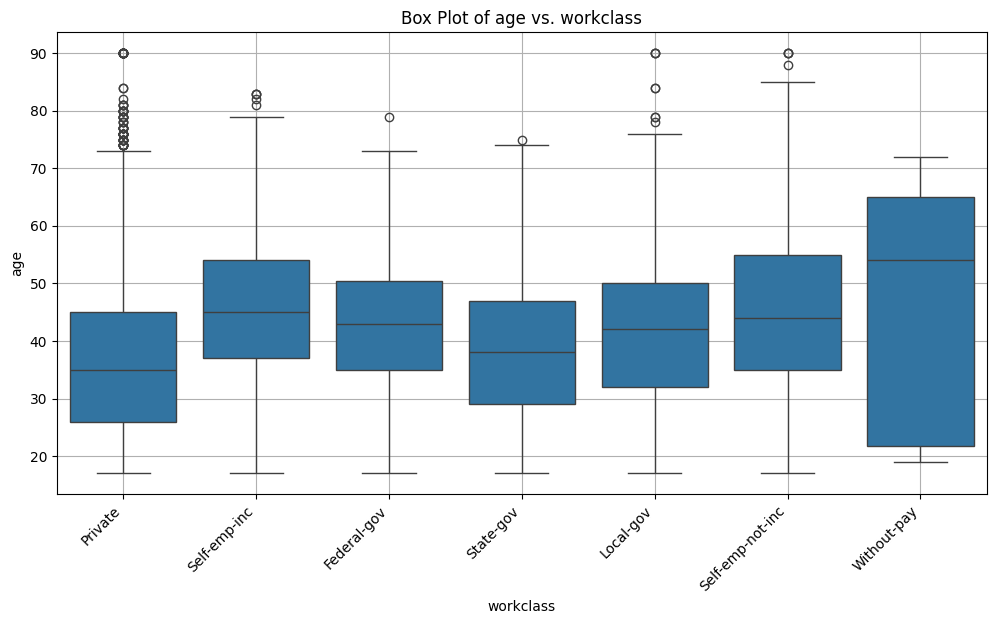

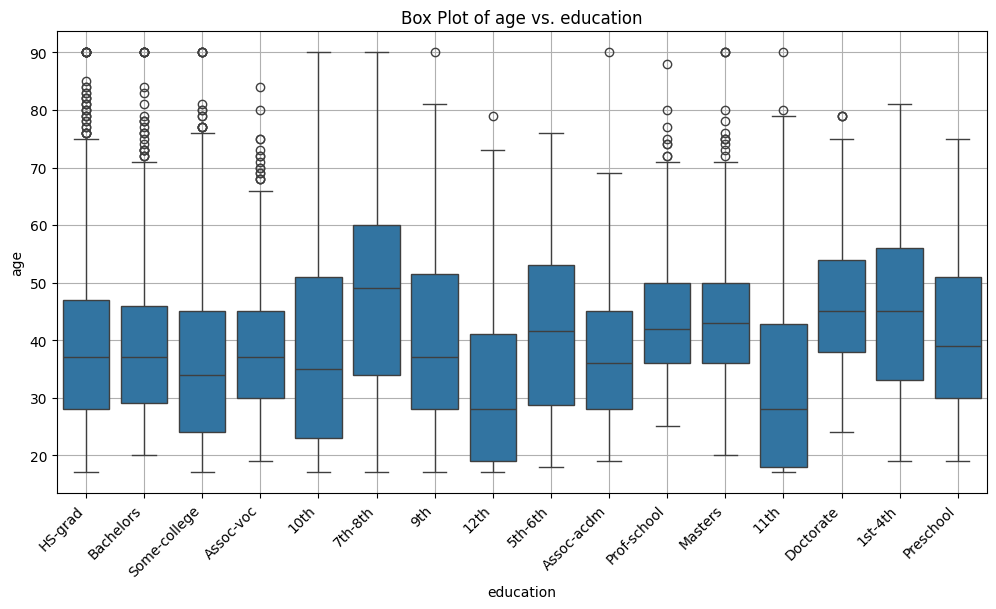

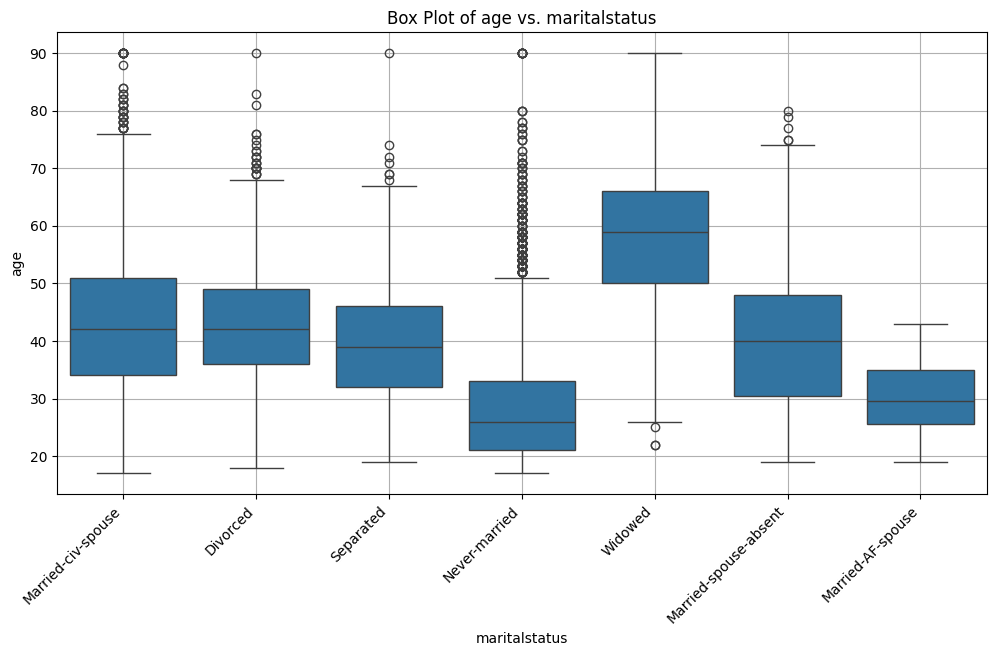

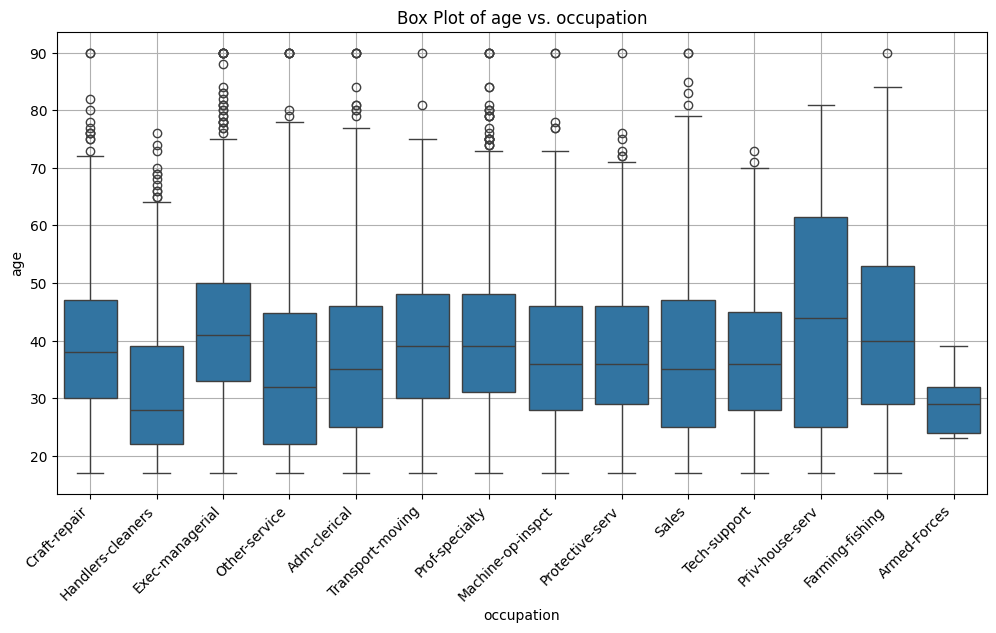

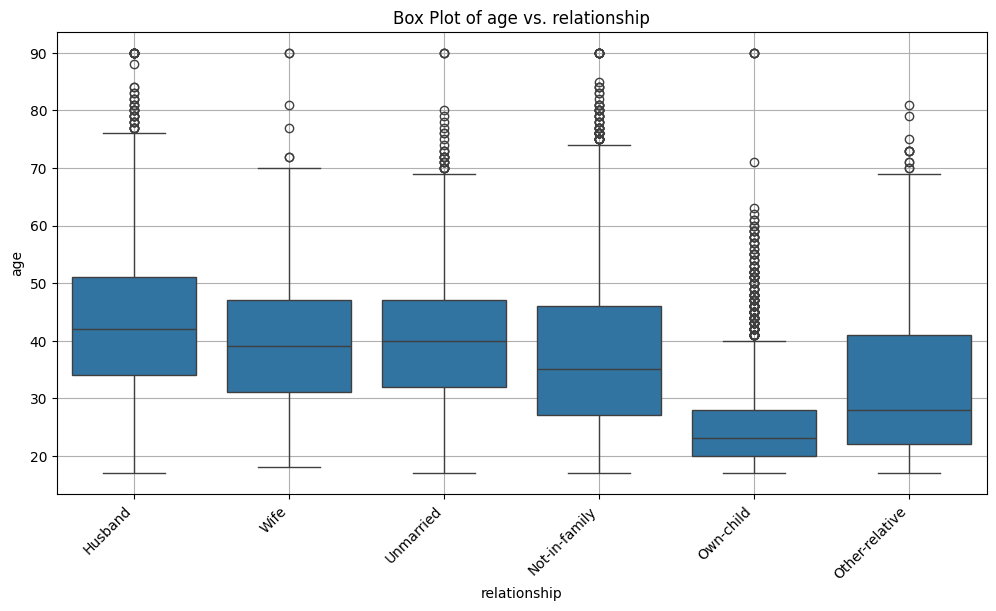

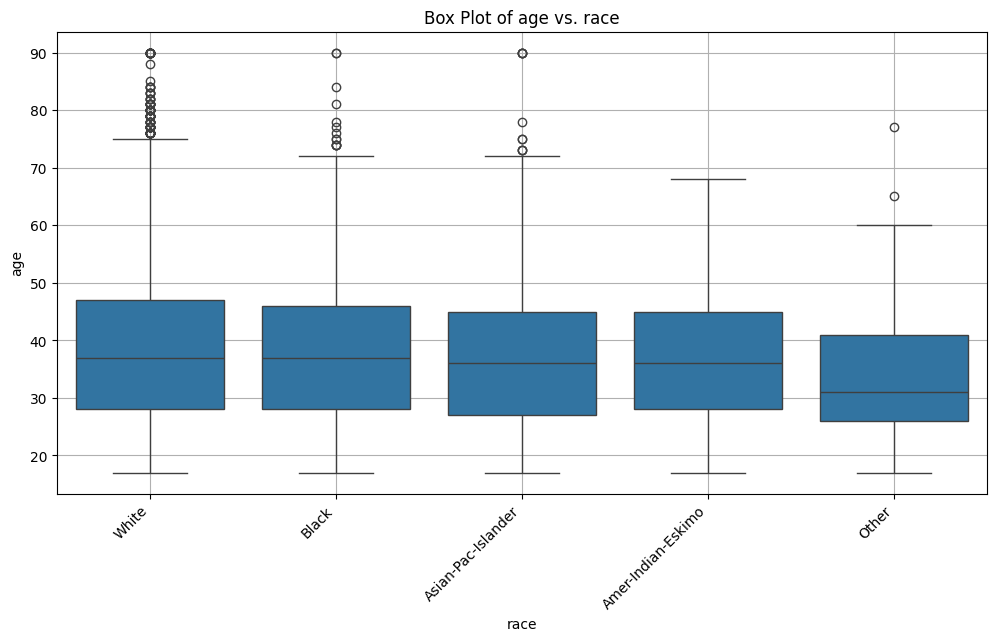

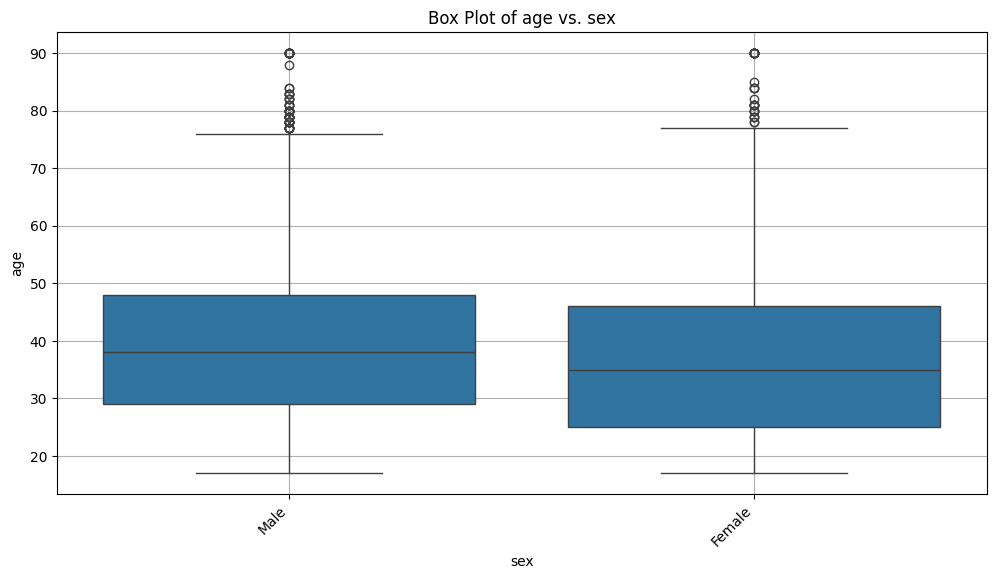

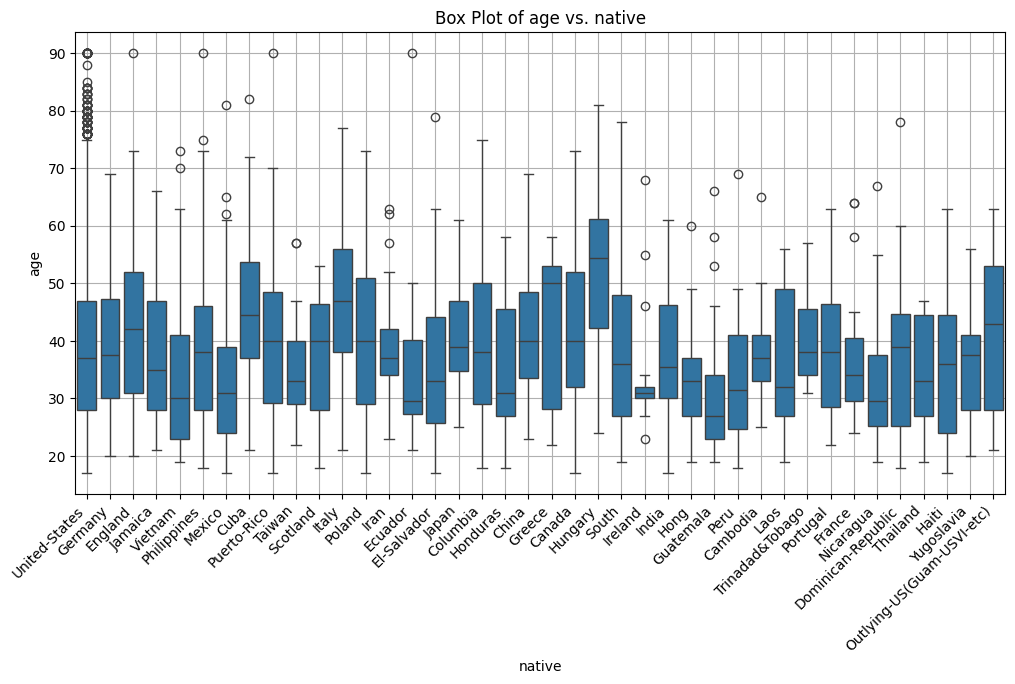

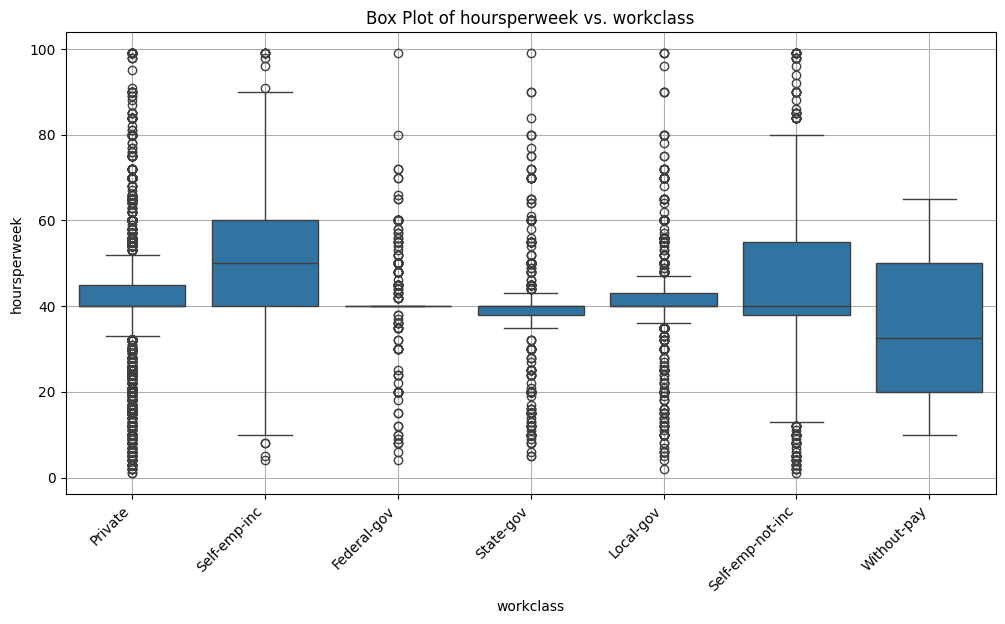

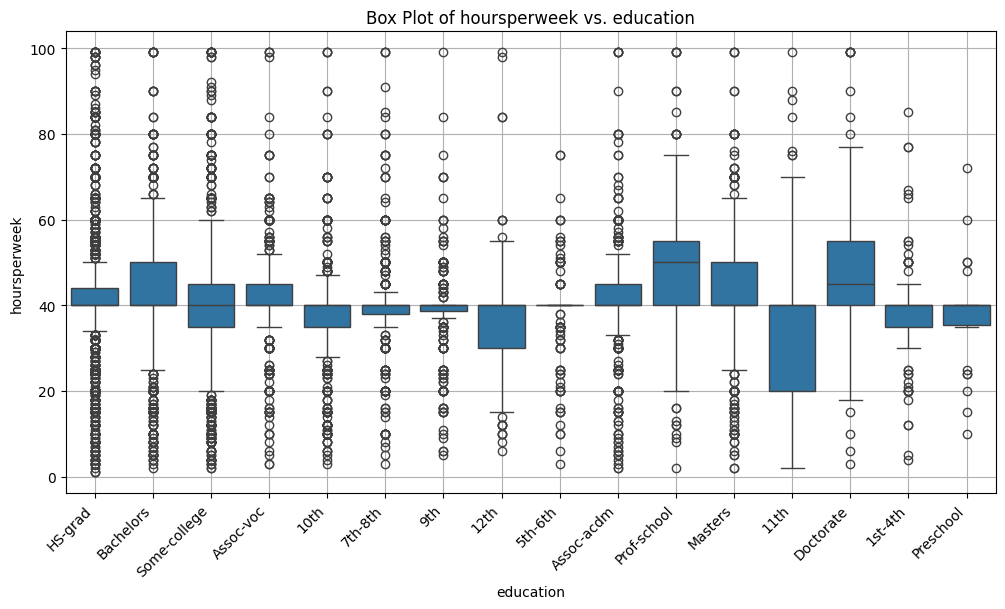

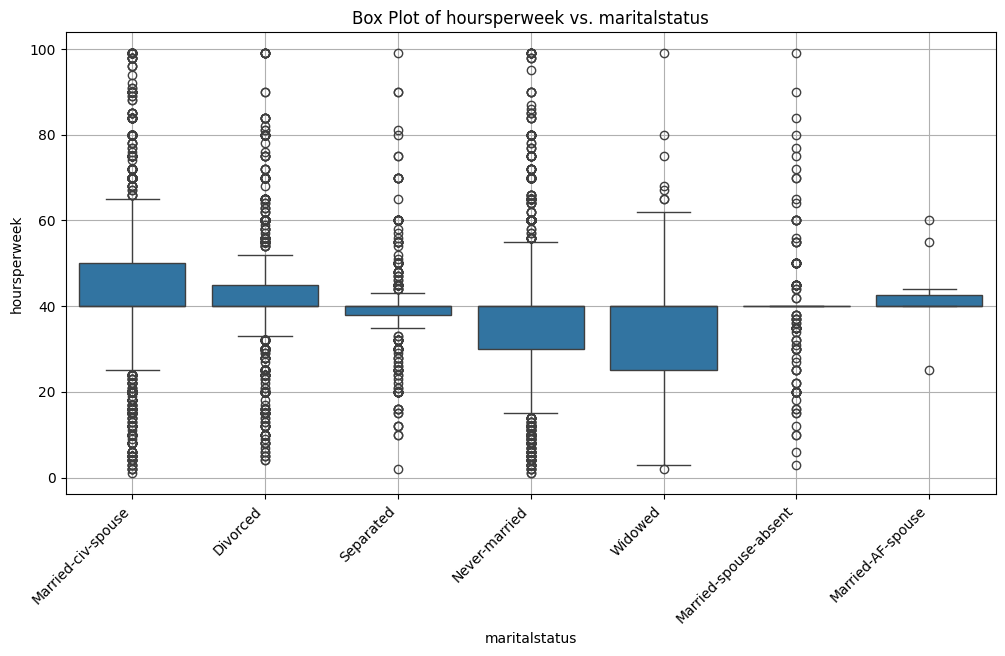

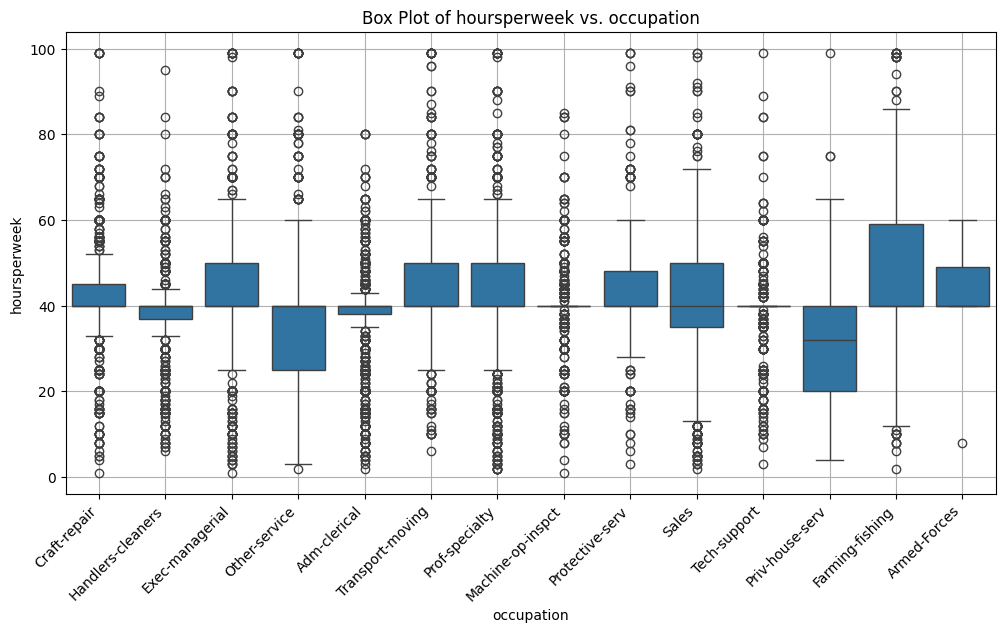

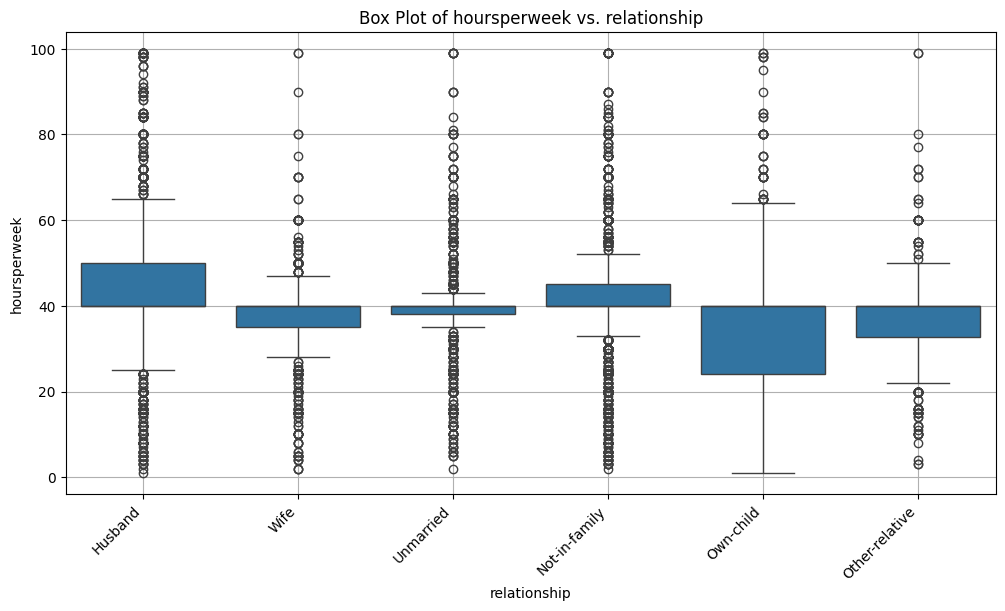

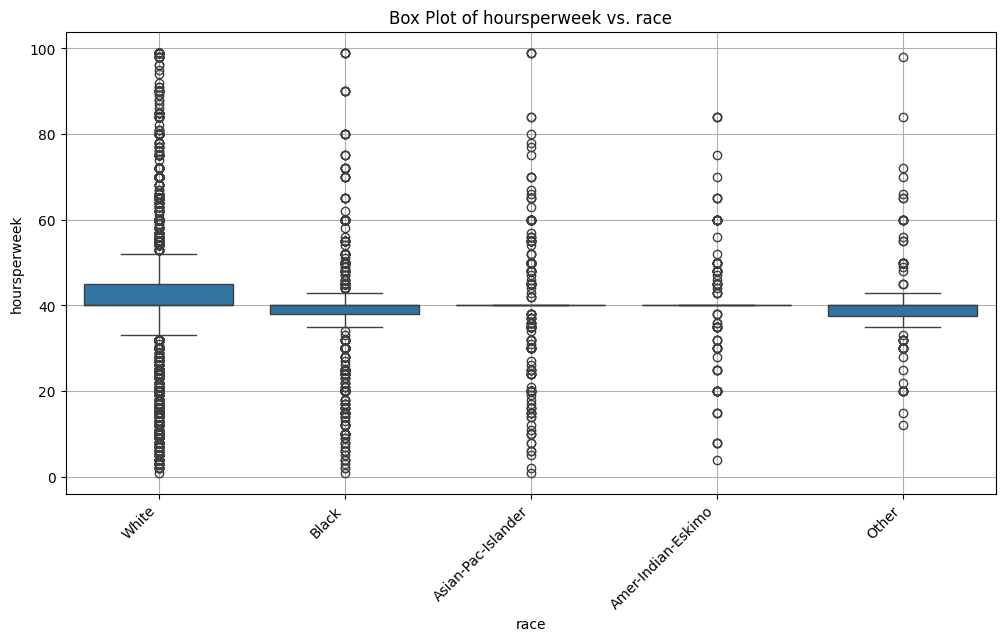

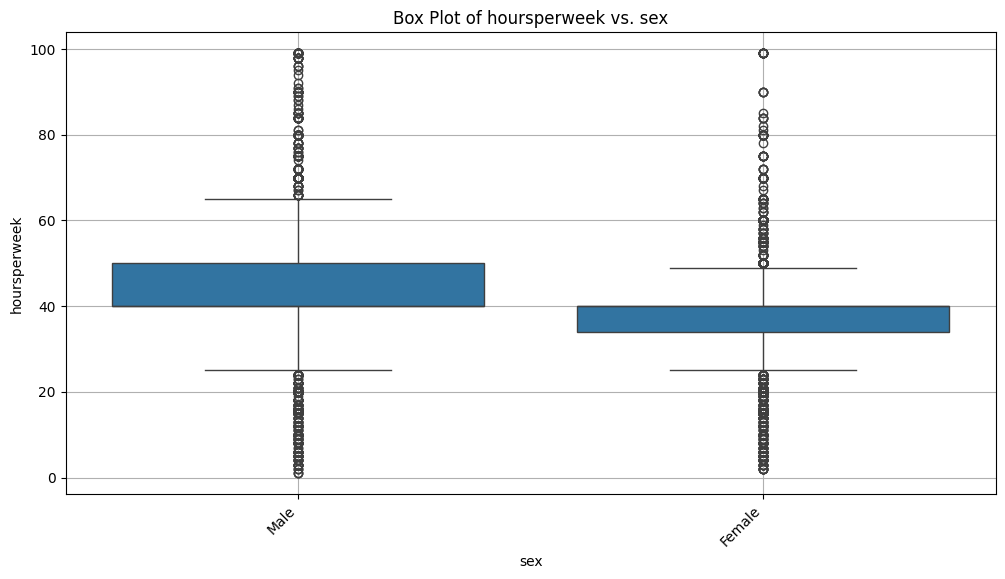

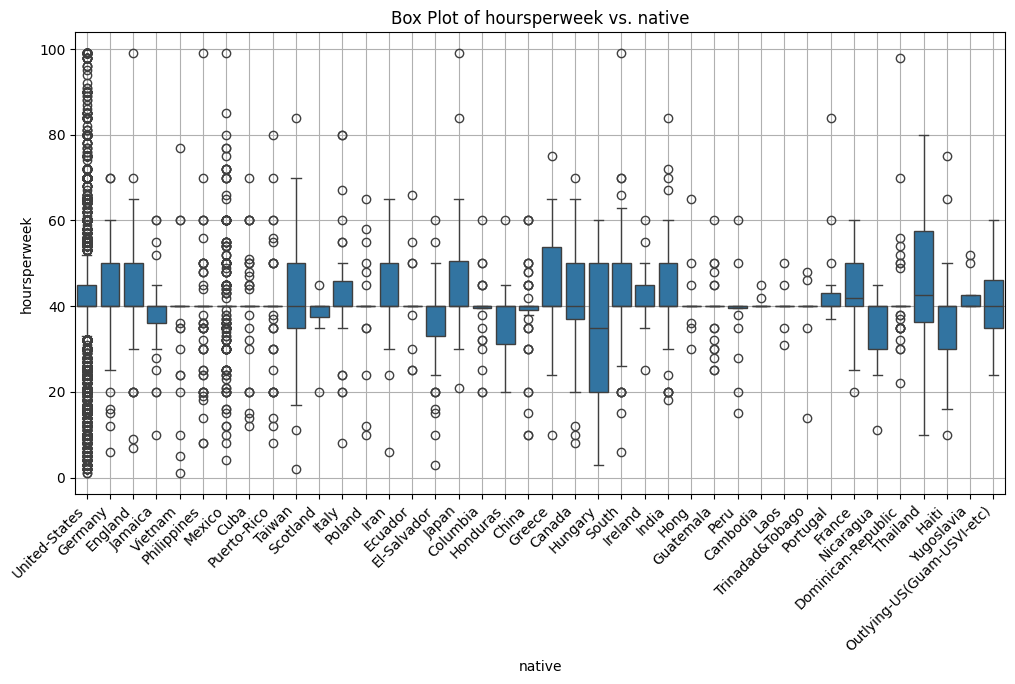

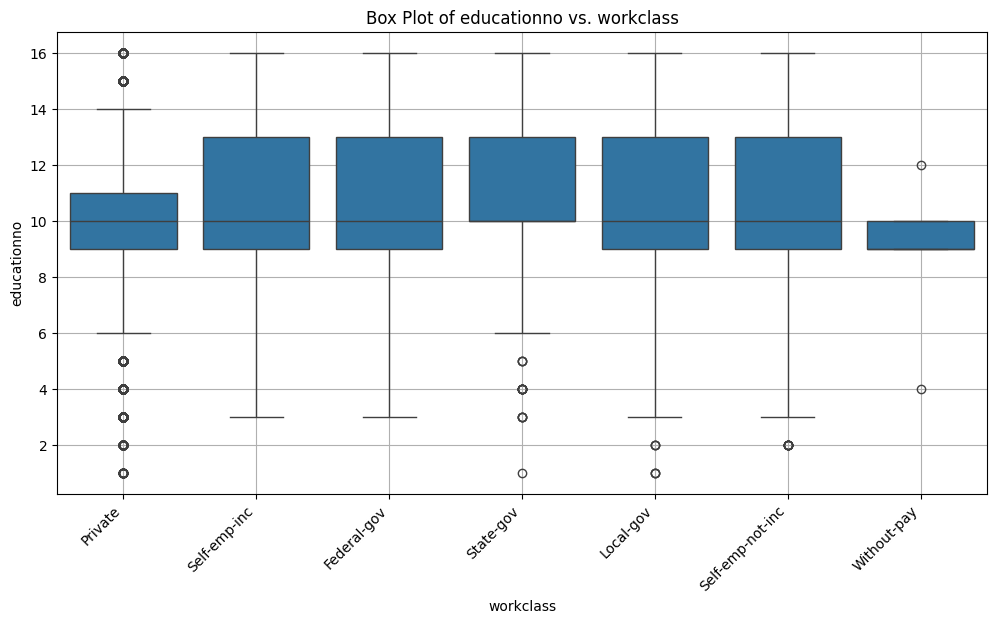

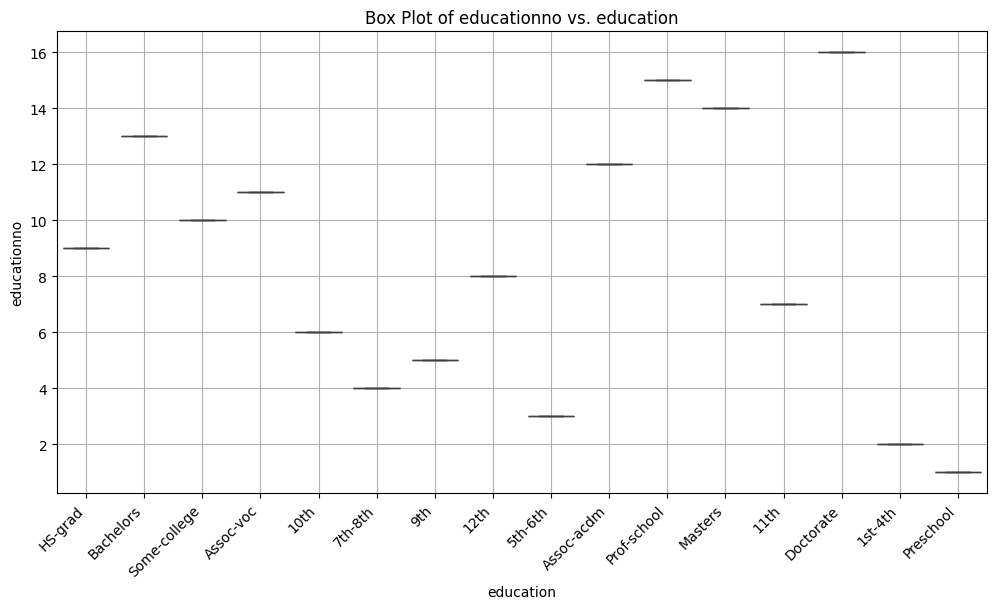

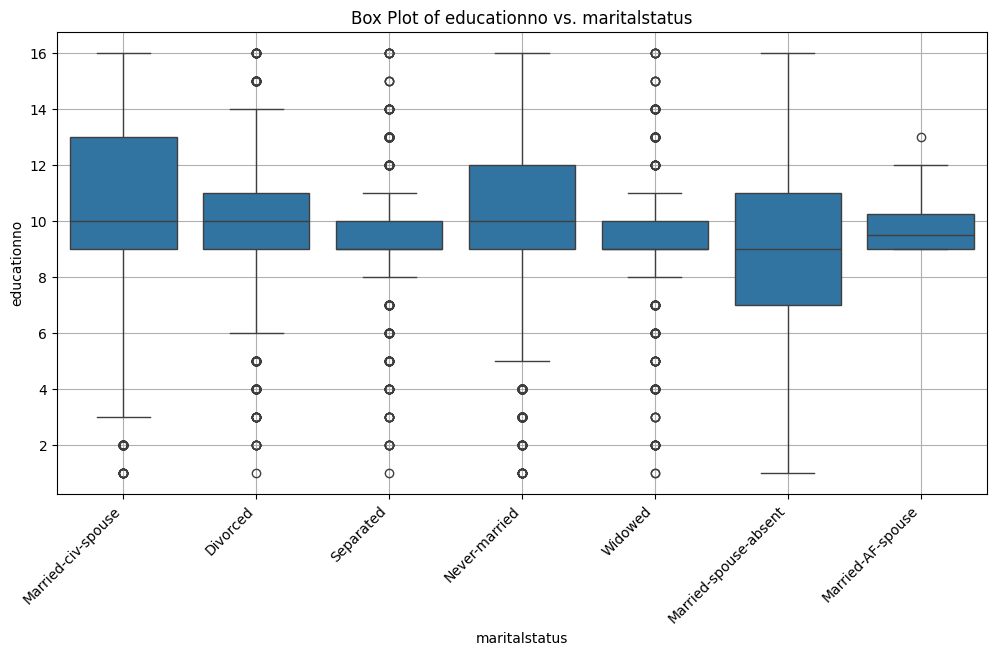

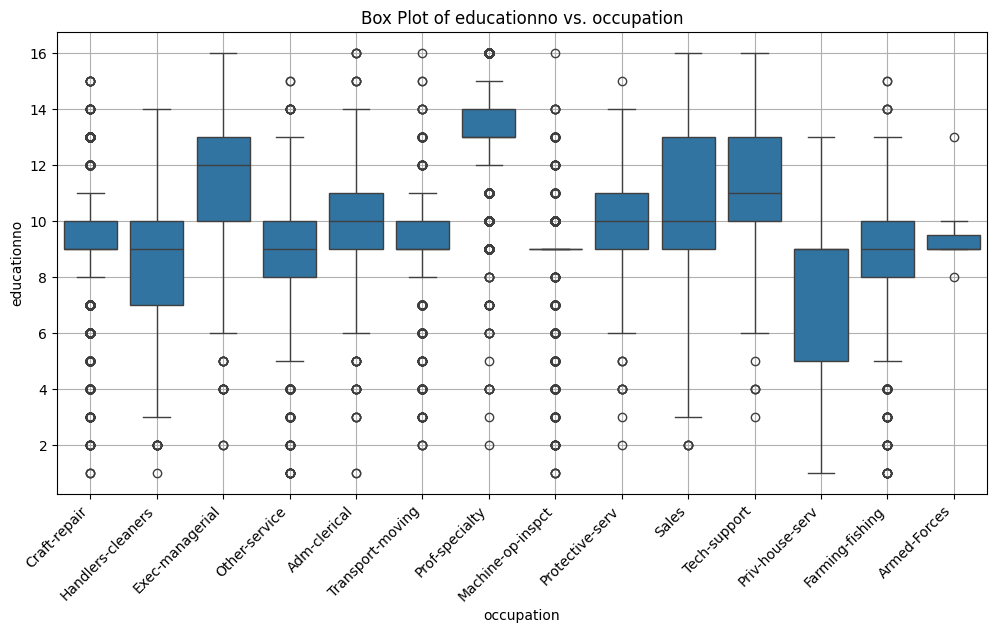

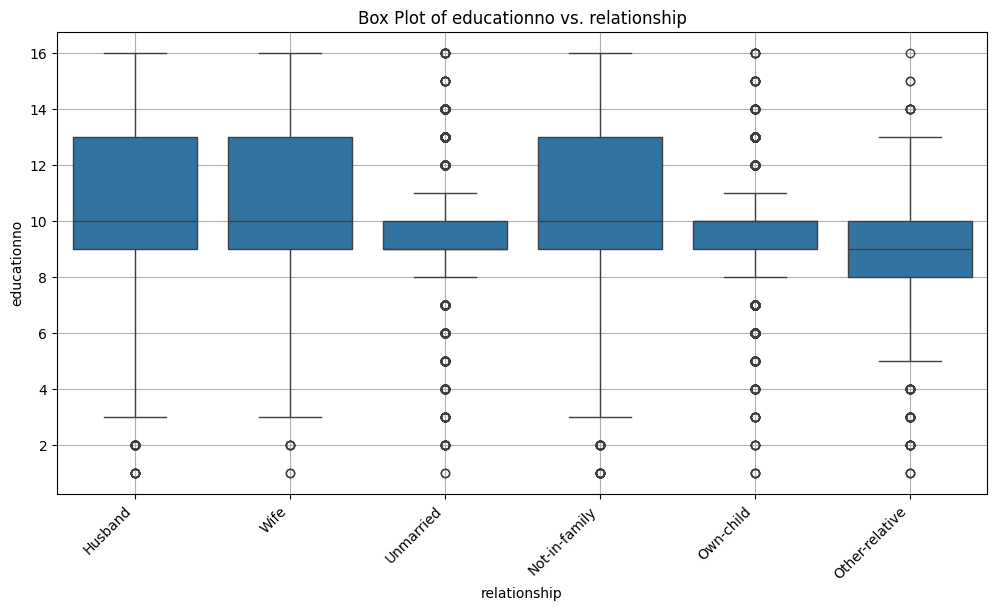

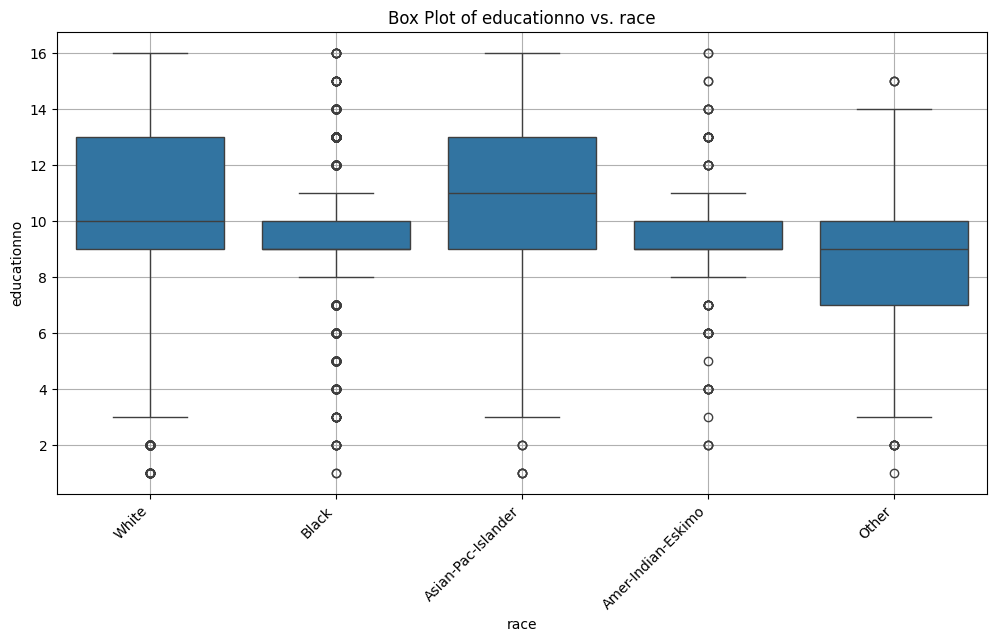

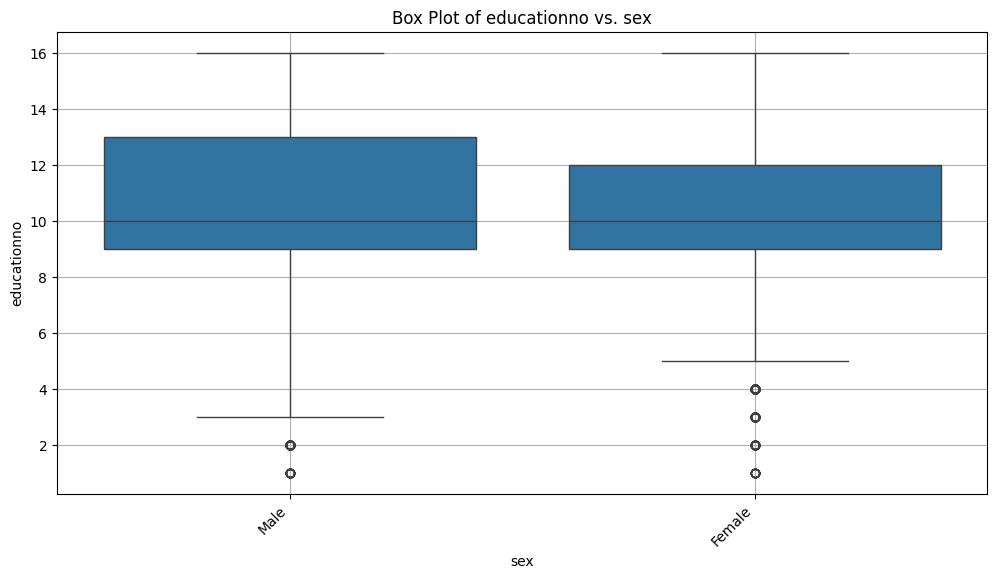

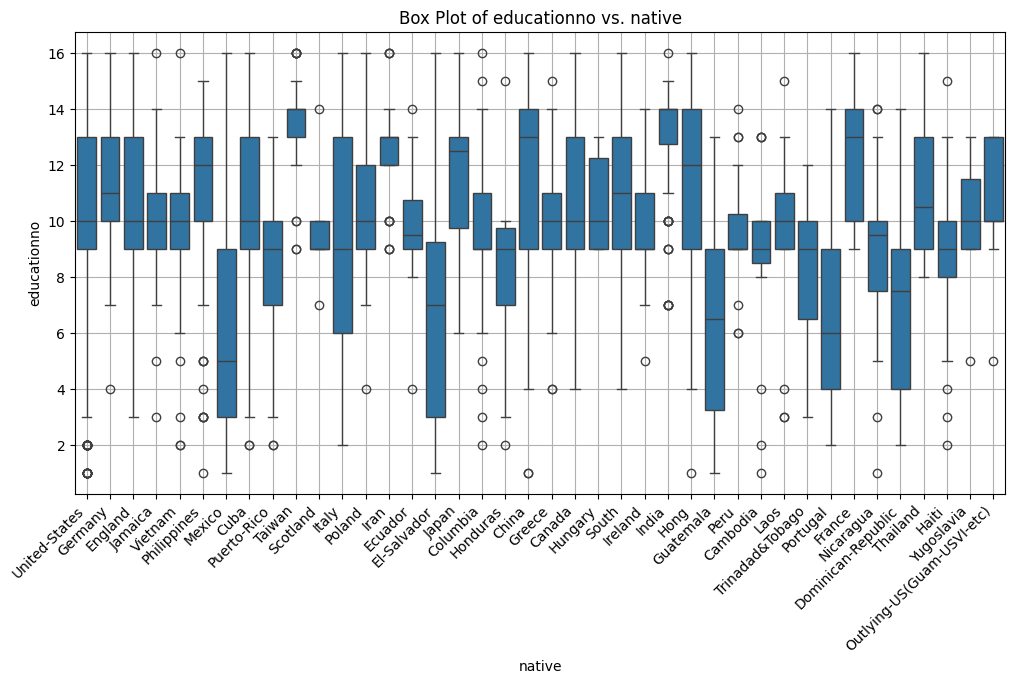

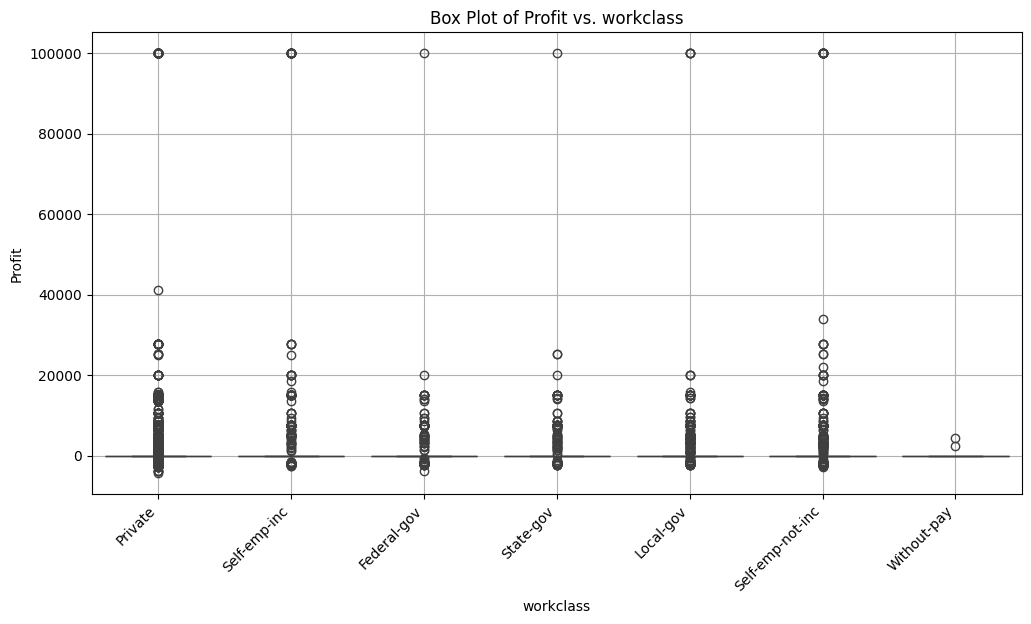

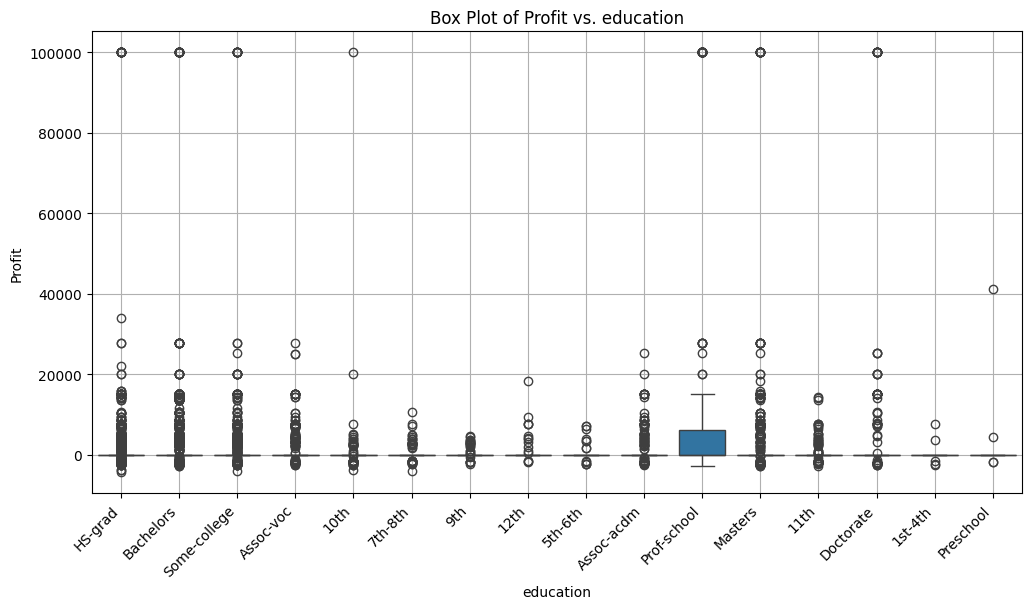

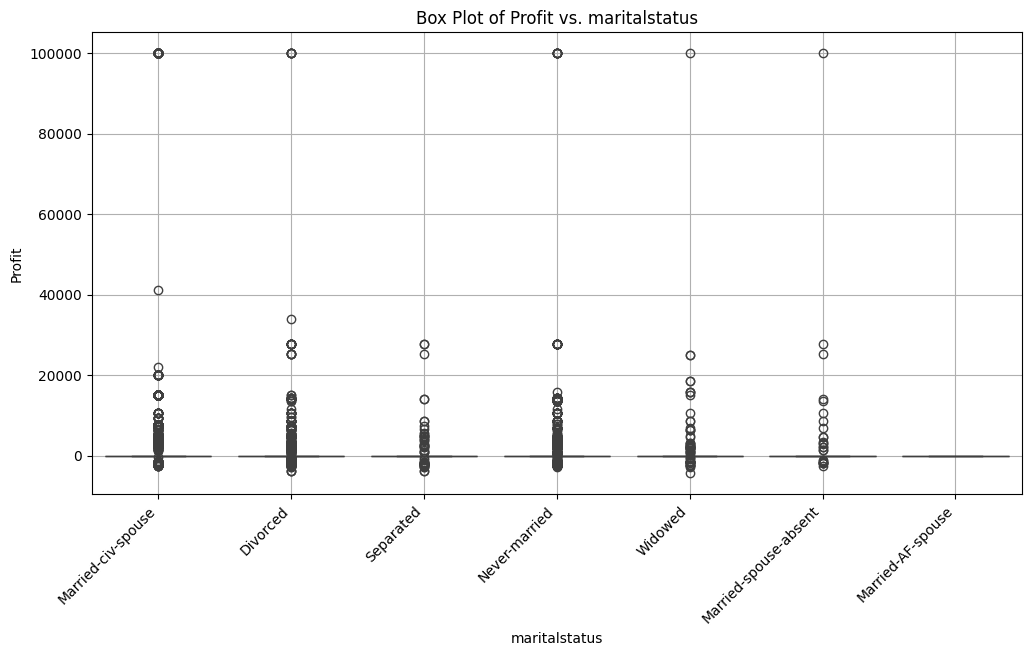

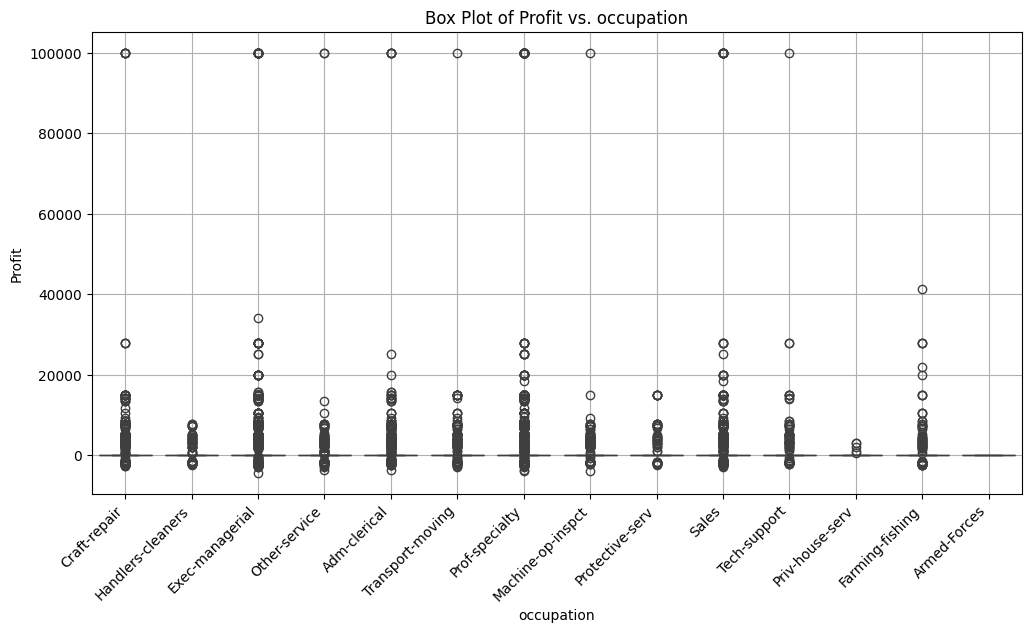

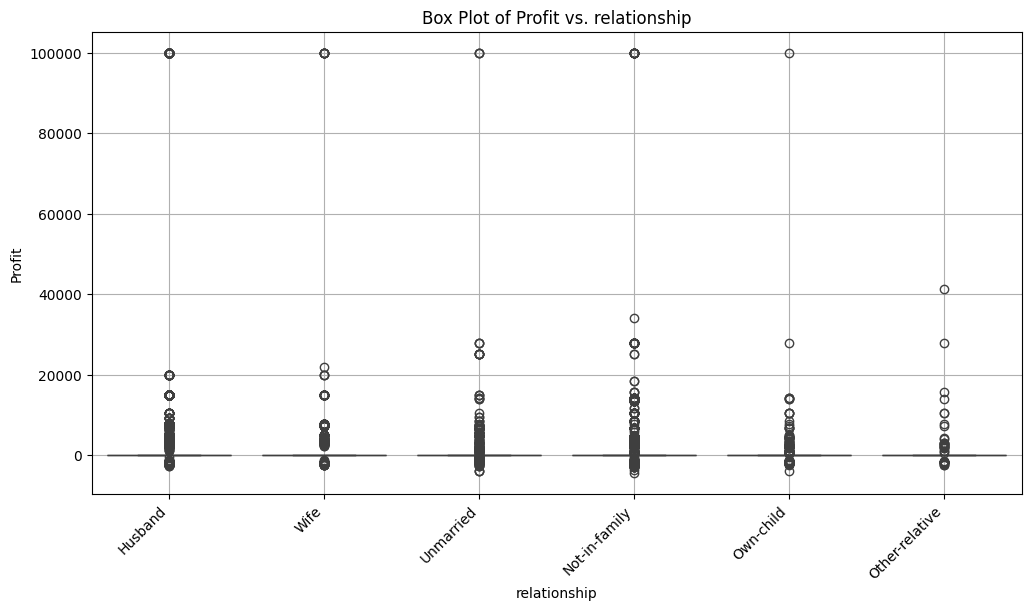

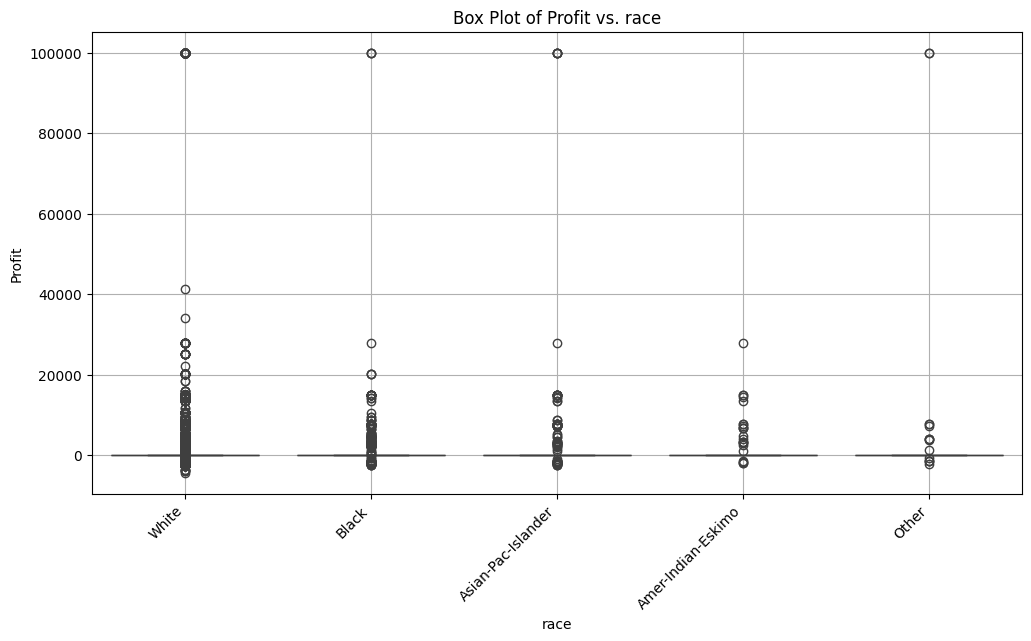

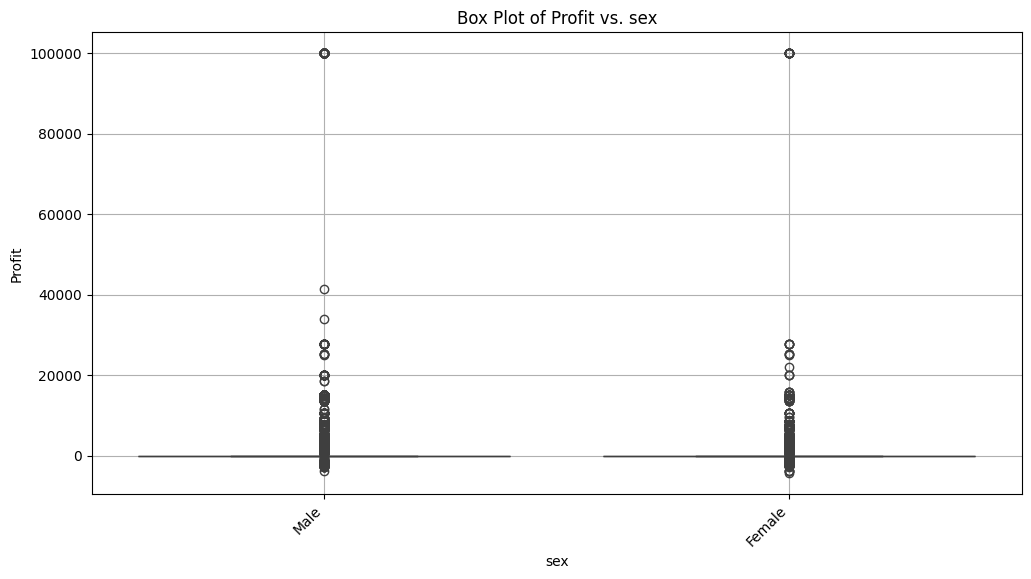

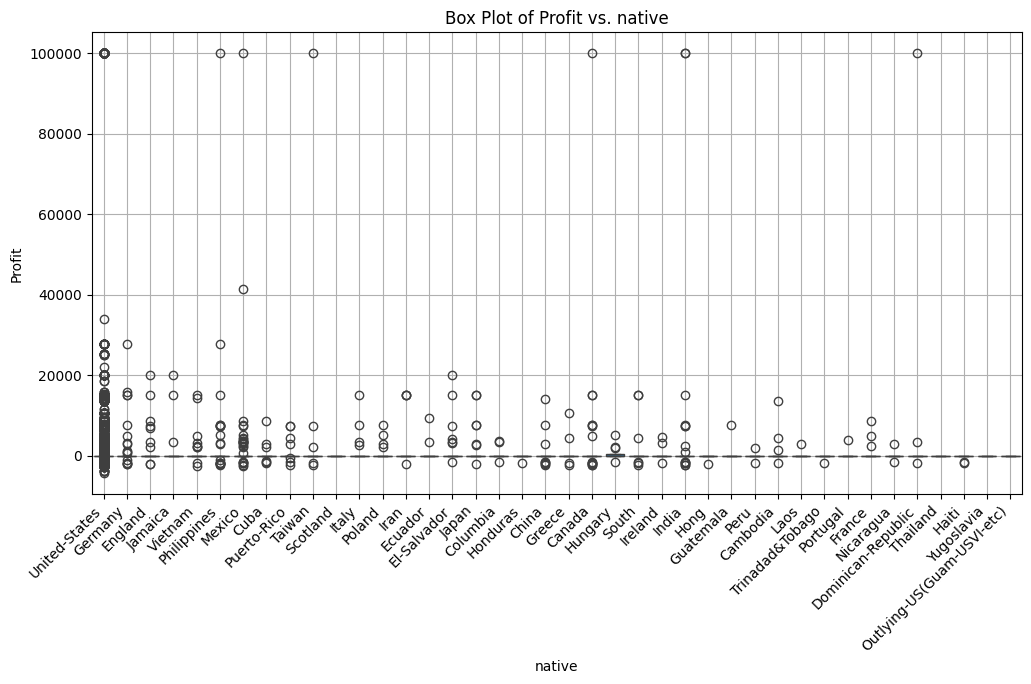

In [ ]:
for num_col in numerical_cols:
    for cat_col in categorical_columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.title(f'Box Plot of {num_col} vs. {cat_col}')
        plt.xticks(rotation=45, ha='right')
        plt.grid(True)
        plt.show()

## 4) Scatter plots

## Correlation heatmap

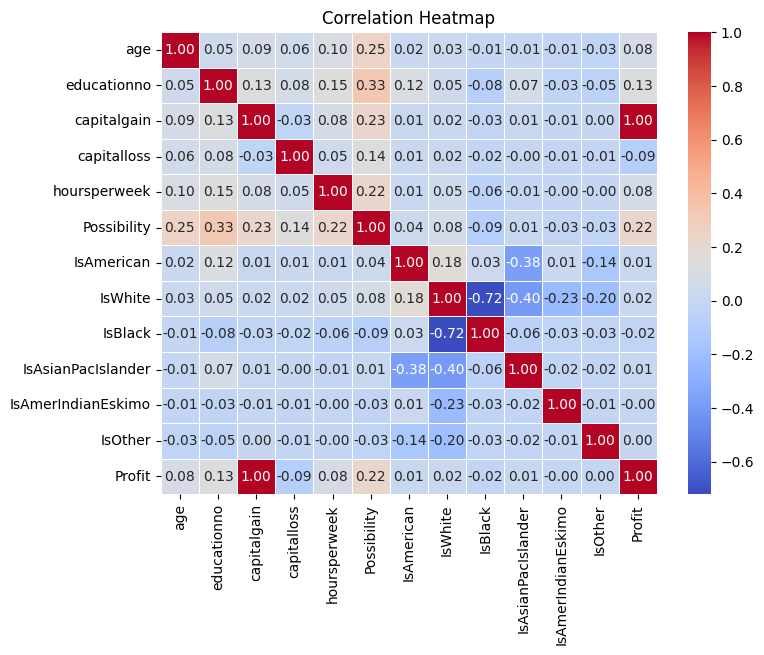

In [ ]:
numerical_df = df.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()